# Table of contents

* **Introduction**
* **Objective**
* **Pipeline Overview**
* **Data Dictionary**
* **Approach**
* **Foundations**
* **Setup Environments**
* **Data Loading**
* **Initial Data Preprocessing**
* **Train and Test Data Split**
* **Exploratory Data Analysis (EDA)**
* **Features Engineering**
    * Features and Target Labels Split
    * Data Cleaning
    * Target Labels Encoding
    * Text Representation (TF-IDF)
    * Oversampling (ADASYN)
    * Dimensionality Reduction (PCA)
* **Model Training**
    * Weak Learner Model Selection
    * Decision Boundary Visualization (Weak Learner)
    * Ensemble Model Selection
    * Decision Boundary (Ensemble Model)
    * Hyperparameters Tuning (Optuna)
    * Final Model Training (Best Hyperparameters)
    * Decision Boundary (Final Model)
* **Model Evaluation**
    * Classification Reports
    * Confusion Matrix
    * Precision Recall Curve
    * ROC-AUC Curve
    * Model Inference Testing
* **Conclusion**
* **References**

# Introduction

Text classification is a fundamental task in Natural Language Processing (NLP) where the goal is to assign predefined categories to text data. In this tutorial, it focuses on classifying SMS messages as either "Spam" or "Not spam" using the SMS Spam Collection dataset. It will cover the entire machine learning pipeline, from data preprocessing to model evaluation, and explore key concepts and techniques used in text classification.

# Objective

The objective of this tutorial is to build a robust machine learning model to classify SMS messages as spam or not spam with high accuracy. It aims to preprocess the text data, handle class imbalance, train multiple machine learning models, and evaluate their performance using appropriate metrics. By the end, it will demonstrate how to perform inference on custom text inputs.

# Pipeline Overview

The machine learning pipeline for this text classification task includes the following steps:
1. **Data Loading and Preprocessing**: Load the SMS dataset, clean the text, and prepare it for modeling.
2. **Feature Engineering**: Convert text data into numerical features using TF-IDF vectorization.
3. **Handling Class Imbalance**: Use ADASYN oversampling to address the imbalance between spam and non-spam messages.
4. **Dimensionality Reduction**: Apply PCA to reduce feature dimensions for visualization and modeling.
5. **Model Training**: Train multiple machine learning models and an ensemble model with hyperparameter tuning.
6. **Model Evaluation**: Evaluate models using accuracy, precision, recall, F1-score, confusion matrix, and ROC/PR curves.
7. **Inference**: Perform predictions on custom text inputs.

# Data Dictionary

**SMS Spam Collection Data Dictionary**

<style type="text/css">
.tg  {border-collapse:collapse;border-spacing:0;}
.tg td{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  overflow:hidden;padding:10px 5px;word-break:normal;}
.tg th{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  font-weight:normal;overflow:hidden;padding:10px 5px;word-break:normal;}
.tg .tg-za14{border-color:inherit;text-align:left;vertical-align:bottom}
.tg .tg-7zrl{text-align:left;vertical-align:bottom}
</style>
<table class="tg"><thead>
  <tr>
    <th class="tg-za14">Column Name</th>
    <th class="tg-7zrl">Description</th>
    <th class="tg-7zrl">Data Type</th>
    <th class="tg-7zrl">Notes</th>
  </tr></thead>
<tbody>
  <tr>
    <td class="tg-7zrl">v1</td>
    <td class="tg-7zrl">This column contains the label for each SMS message, indicating whether it is legitimate (ham) or spam.</td>
    <td class="tg-7zrl">Categorical (String)</td>
    <td class="tg-7zrl">This is the target variable for a classification task.</td>
  </tr>
  <tr>
    <td class="tg-7zrl">v2</td>
    <td class="tg-7zrl">This column contains the raw text of the SMS message itself.</td>
    <td class="tg-7zrl">Text (String)</td>
    <td class="tg-7zrl">This is the feature variable. It requires preprocessing (e.g.,&nbsp;&nbsp;&nbsp;tokenization, stemming, stop-word removal) before being used in a machine&nbsp;&nbsp;&nbsp;learning model.</td>
  </tr>
</tbody>
</table>

[**Dataset Link**](https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset)

# Approach

**Preprocess Pipeline Approach**

Text preprocessing is critical for transforming raw text into a format suitable for machine learning. The preprocessing pipeline includes:
- **Expanding Contractions**: Using the `contractions` library to expand contractions (e.g., "I'm" to "I am").
- **Removing Special Characters**: Using regex to remove emojis, punctuation, and non-ASCII characters, and converting text to lowercase.
- **Tokenization**: Splitting text into individual words using NLTK's `word_tokenize`.
- **Stopword Removal**: Removing common words (e.g., "the", "is") that do not contribute significantly to meaning, using NLTK's stopword list.
- **Lemmatization**: Reducing words to their base form (e.g., "running" to "run") using NLTK's `WordNetLemmatizer`.
- **TF-IDF Vectorization**: Converting text to numerical features using Term Frequency-Inverse Document Frequency (TF-IDF) with a maximum of 40 features (based on the longest word length observed in the data).
- **Handling Class Imbalance**: Using ADASYN to oversample the minority class (spam) to balance the dataset.

**Model Training Approach**

This notebook employs multiple machine learning models and an ensemble model to classify SMS messages. The models include:
- **Logistic Regression**: A linear model that predicts probabilities for binary classification using a logistic function.
- **K-Nearest Neighbors (KNN)**: A non-parametric model that classifies based on the majority class of the nearest neighbors in the feature space.
- **Decision Tree**: A tree-based model that splits the feature space based on feature values to make decisions.
- **Random Forest**: An ensemble of decision trees that improves robustness by averaging predictions.
- **XGBoost**: A gradient boosting framework that optimizes decision trees iteratively to minimize a loss function.
- **LightGBM**: A gradient boosting framework optimized for speed and efficiency, particularly for large datasets.
- **CatBoost**: A gradient boosting algorithm designed to handle categorical features and avoid overfitting.
- **Voting Classifier**: An ensemble model that combines predictions from multiple base models using soft voting (weighted average of probabilities).
- **Stacking Classifier**: An ensemble model that uses a meta-learner to combine predictions from base models.

**Hyperparameter Tuning**

This notebook uses **Optuna** to perform hyperparameter optimization for the Voting Classifier, tuning parameters for each base model and their weights in the ensemble. The objective is to maximize the mean cross-validation accuracy over 5 folds.

**Model Evaluation Approach**

This notebook evaluates the models using the following metrics:
- **Accuracy**: The proportion of correct predictions.
- **Precision**: The proportion of true positive predictions among all positive predictions.
- **Recall**: The proportion of true positive predictions among all actual positives.
- **F1-Score**: The harmonic mean of precision and recall, balancing the two metrics.
- **Confusion Matrix**: A table showing true positives, true negatives, false positives, and false negatives.
- **Precision-Recall Curve**: A plot showing the trade-off between precision and recall for different thresholds.
- **ROC-AUC Curve**: A plot showing the trade-off between true positive rate (recall) and false positive rate, with the area under the curve (AUC) indicating model performance.

**Visualization**

- **Decision Boundaries**: Visualized using PCA-reduced data to show how models separate classes in a 2D feature space.
- **Word Cloud**: Displays frequent words in the dataset to understand key terms.
- **Stopword Frequency**: Plots the top 20 stopwords to highlight their prevalence before removal.

# Foundations

**Preprocessing**

- **TF-IDF (Term Frequency-Inverse Document Frequency)**: A numerical statistic that reflects the importance of a word in a document relative to a collection of documents. It emphasizes words that are frequent in a document but rare across the corpus.
- **Tokenization**: The process of breaking down text into smaller units (tokens), typically words, to facilitate analysis.
- **Stopwords**: Common words that are often removed to reduce noise in text data, as they carry little semantic meaning.
- **Lemmatization**: Reducing words to their base or dictionary form to normalize text data, unlike stemming, which may produce non-words.
- **Class Imbalance**: When one class (e.g., not spam) dominates the dataset, leading to biased models. Techniques like ADASYN generate synthetic samples for the minority class to balance the dataset.

**Model Training**

- **Supervised Learning**: The task of learning a function that maps input features to output labels based on labeled training data.
- **Ensemble Learning**: Combining multiple models to improve performance. Voting Classifier uses weighted averaging, while Stacking Classifier uses a meta-learner.
- **Cross-Validation**: A technique to assess model performance by splitting data into k folds, training on k-1 folds, and testing on the remaining fold, repeated k times.
- **Hyperparameter Tuning**: The process of optimizing model parameters to improve performance, using tools like Optuna for efficient search.
- **Gradient Boosting**: An ensemble technique that builds models sequentially, with each model correcting errors of the previous ones by minimizing a loss function.

**Model Evaluation**

- **Confusion Matrix**: Provides a detailed breakdown of classification performance, useful for imbalanced datasets.
- **Precision-Recall Curve**: Particularly useful for imbalanced datasets, as it focuses on the minority class performance.
- **ROC-AUC**: Measures the model's ability to distinguish between classes, with higher AUC indicating better performance.
- **Principal Component Analysis (PCA)**: A dimensionality reduction technique that projects high-dimensional data into a lower-dimensional space while preserving variance.

# Setup Environments

**Packages Installation**

In [ ]:
%%capture
!pip install imblearn contractions catboost optuna --upgrade catboost xgboost lightgbm

**Import Libraries**

In [ ]:
import re
import string
import warnings
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import contractions
from wordcloud import WordCloud

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

from sklearn.model_selection import (
    train_test_split, cross_val_score
)
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.ensemble import (
    VotingClassifier, RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, HistGradientBoostingClassifier, ExtraTreesClassifier,
    BaggingClassifier, StackingClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, f1_score,
    precision_score, recall_score, precision_recall_curve, roc_curve, roc_auc_score,
    make_scorer
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier, RadiusNeighborsClassifier
from sklearn.datasets import make_classification, make_moons
from sklearn.multiclass import OneVsRestClassifier

from imblearn.over_sampling import RandomOverSampler, ADASYN

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

warnings.filterwarnings('ignore')

[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


# Data Loading

In [4]:
df = pd.read_csv('/kaggle/input/sms-spam-collection-dataset/spam.csv',delimiter=',',encoding='latin-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


# Initial Data Preprocessing

In [5]:
df = df[['v1','v2']]
df = df.rename(columns={'v1': 'Label', 'v2': 'Text'})
df['Label'] = df['Label'].replace({'ham': 'Not spam', 'spam': 'Spam'})
df

,Label,Text
0,Not spam,"Go until jurong point, crazy.. Available only ..."
1,Not spam,Ok lar... Joking wif u oni...
2,Spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,Not spam,U dun say so early hor... U c already then say...
4,Not spam,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,Spam,This is the 2nd time we have tried 2 contact u...
5568,Not spam,Will Ì_ b going to esplanade fr home?
5569,Not spam,"Pity, * was in mood for that. So...any other s..."
5570,Not spam,The guy did some bitching but I acted like i'd...


# Train and Test Data Split

The goal of data splitting is to create independent datasets for training and testing, which is fundamental for validating a machine learning model.

**Data Leakage:** Machine learning models must generalize well to new, unseen data, not just memorize the training examples. By separating the data into a training set (for learning parameters) and a test set (for final, unbiased performance evaluation), we can measure the model's true generalization ability.

- Test Set Ratio (`test_size=0.2`): This allocates $20\%$ of the total data for testing and $80\%$ for training. This $80/20$ split is a common heuristic in machine learning, though it can vary based on dataset size.
- Reproducibility (`random_state=42`): This is a random seed. Setting a fixed seed ensures that the data is split in exactly the same way every time the code is run. This is essential for reproducibility in research and development.

In [ ]:
train, test = train_test_split(df, test_size=0.2, random_state=42) 

print("train shape:", train.shape)
print("test shape:", test.shape)

train shape: (4457, 2)
test shape: (1115, 2)


# Exploratory Data Analysis (EDA)

EDA uses visualization and statistics to summarize data properties, inform feature engineering, and identify potential challenges.

**Check Dataset Information**

After splitting, it's vital to ensure data quality and structure are maintained:

- `train.isnull().sum() and test.isnull().sum()`: This checks for missing values (NaN or null entries). In many datasets, missing values require imputation or removal, as they can break downstream processing or confuse models.
- `train.info() and test.info()`: Provides a high-level summary of the dataframes, including the number of entries, columns, non-null values, and data types (Dtype). This confirms the datasets are loaded correctly and that the text data is stored as a suitable object type (string).

In [7]:
train.head()

,Label,Text
1978,Not spam,No I'm in the same boat. Still here at my moms...
3989,Spam,(Bank of Granite issues Strong-Buy) EXPLOSIVE ...
3935,Not spam,They r giving a second chance to rahul dengra.
4078,Not spam,O i played smash bros &lt;#&gt; religiously.
4086,Spam,PRIVATE! Your 2003 Account Statement for 07973...


In [8]:
train.isnull().sum()

Label    0
Text     0
dtype: int64

In [9]:
test.isnull().sum()

Label    0
Text     0
dtype: int64

In [10]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4457 entries, 1978 to 860
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Label   4457 non-null   object
 1   Text    4457 non-null   object
dtypes: object(2)
memory usage: 104.5+ KB


In [11]:
test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1115 entries, 3245 to 4293
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Label   1115 non-null   object
 1   Text    1115 non-null   object
dtypes: object(2)
memory usage: 26.1+ KB


**Result**

- **Missing Values:** Both `train.isnull().sum() and test.isnull().sum()` report zero missing values for both the Label and Text columns. This is ideal, as it means no imputation or complex null-handling is required.
- **Data Types:** Both columns are correctly identified as object (string type in Pandas), suitable for text data.

**Label Distribution:**

- Class Imbalance: In classification tasks, an imbalanced dataset occurs when one class is significantly more frequent than others. This is a common challenge, as models tend to become biased toward the majority class.
- `sns.countplot` visually displays the frequency of each class label.

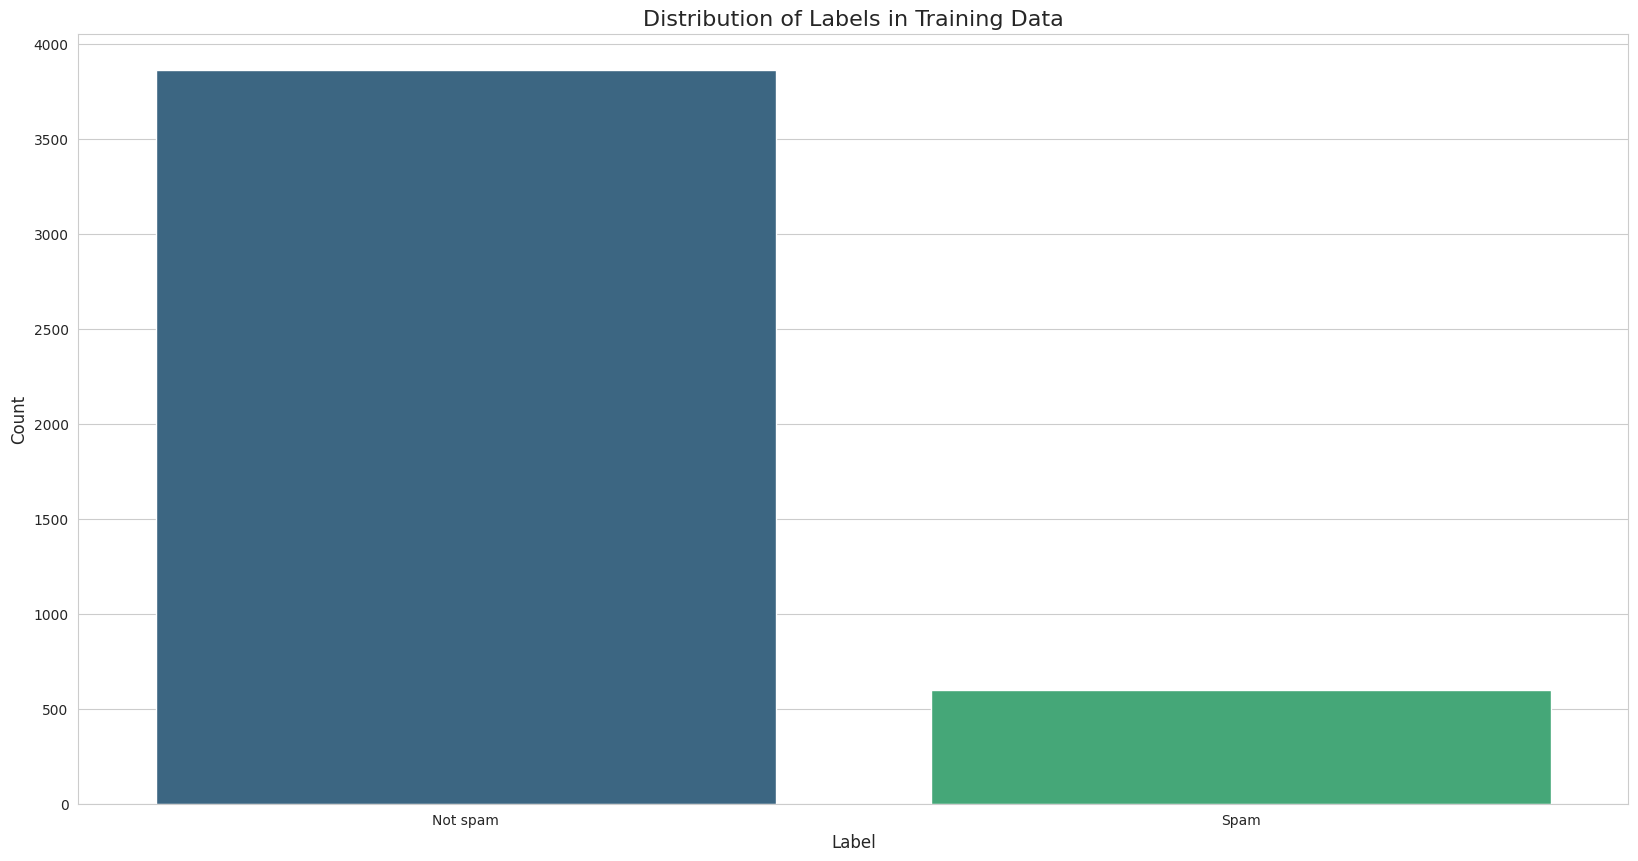

In [ ]:
sns.set_style("whitegrid")

plt.figure(figsize=(20, 10))

sns.countplot(x=train['Label'], palette="viridis")

plt.title('Distribution of Labels in Training Data', fontsize=16)
plt.xlabel('Label', fontsize=12)
plt.ylabel('Count', fontsize=12)

plt.show()

The "Not spam" class is about $7$ times more frequent than the "Spam" class. If this imbalance isn't addressed (e.g., through class weighting, oversampling, or undersampling), the final model is likely to achieve a high apparent accuracy simply by predicting "Not spam" most of the time, while performing poorly on the crucial "Spam" detection task.

**Text Statistics (Longest Word/Total Words):**

- This provides basic characteristics of the vocabulary and text length, which can inform tokenization and model architecture choices (e.g., maximum sequence length).

In [ ]:
full_text = ' '.join(train['Text'])

words = re.findall(r'\b\w+\b', full_text.lower())

longest_word = max(words, key=len)

total_words = len(words)

print(f"Longest word in the training set: '{longest_word}' (length: {len(longest_word)})")
print(f"Total number of words in the training set: {total_words}")

Longest word in the training set: 'hypotheticalhuagauahahuagahyuhagga' (length: 34)
Total number of words in the training set: 71807


- Total Words: The training set contains $71,807$ total words.
- Longest Word: The longest word found is 'hypotheticalhuagauahahuagahyuhagga' (length 34). This suggests the presence of noise, potential misspellings, or highly unusual words that may need to be handled during cleaning.

**Word Cloud:**

- Term Frequency. A Word Cloud visually represents the frequency of words in a corpus. Words that appear more frequently are displayed in a larger font size. It's a quick way to gain qualitative insight into the most common vocabulary.

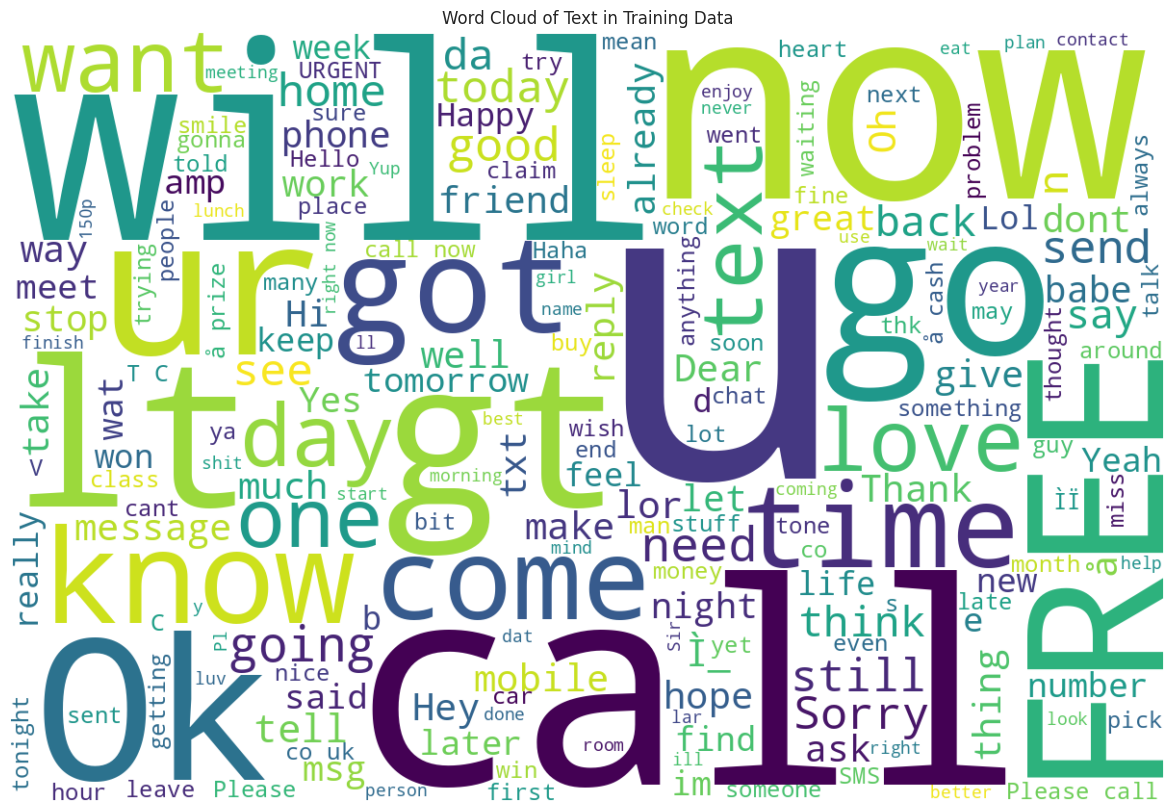

In [ ]:
combined_text = ' '.join(train['Text'])

wordcloud = WordCloud(
    width=1200,
    height=800,
    background_color='white',
    colormap='viridis'
).generate(combined_text)

# Create a plot to display the word cloud
plt.figure(figsize=(20, 10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')  # Turn off the axis labels and ticks
plt.title('Word Cloud of Text in Training Data')
plt.show()

The word cloud shows that words related to communication and action dominate the text:

- High-frequency words include: call, get, now, know, come, and want.
- Phrases like got FREE strongly hint at promotional or spam content, suggesting these words will be highly predictive of the Spam label.

**Stop Word Analysis**

- Stop Words. These are common, high-frequency words (e.g., "the," "a," "is," "to") that carry little semantic meaning for the classification task. They often act as noise in predictive models.The code identifies and counts the top $20$ most frequent English stop words. This analysis is performed to justify a preprocessing step later in the pipeline where these words are removed to improve the model's focus on meaningful tokens.

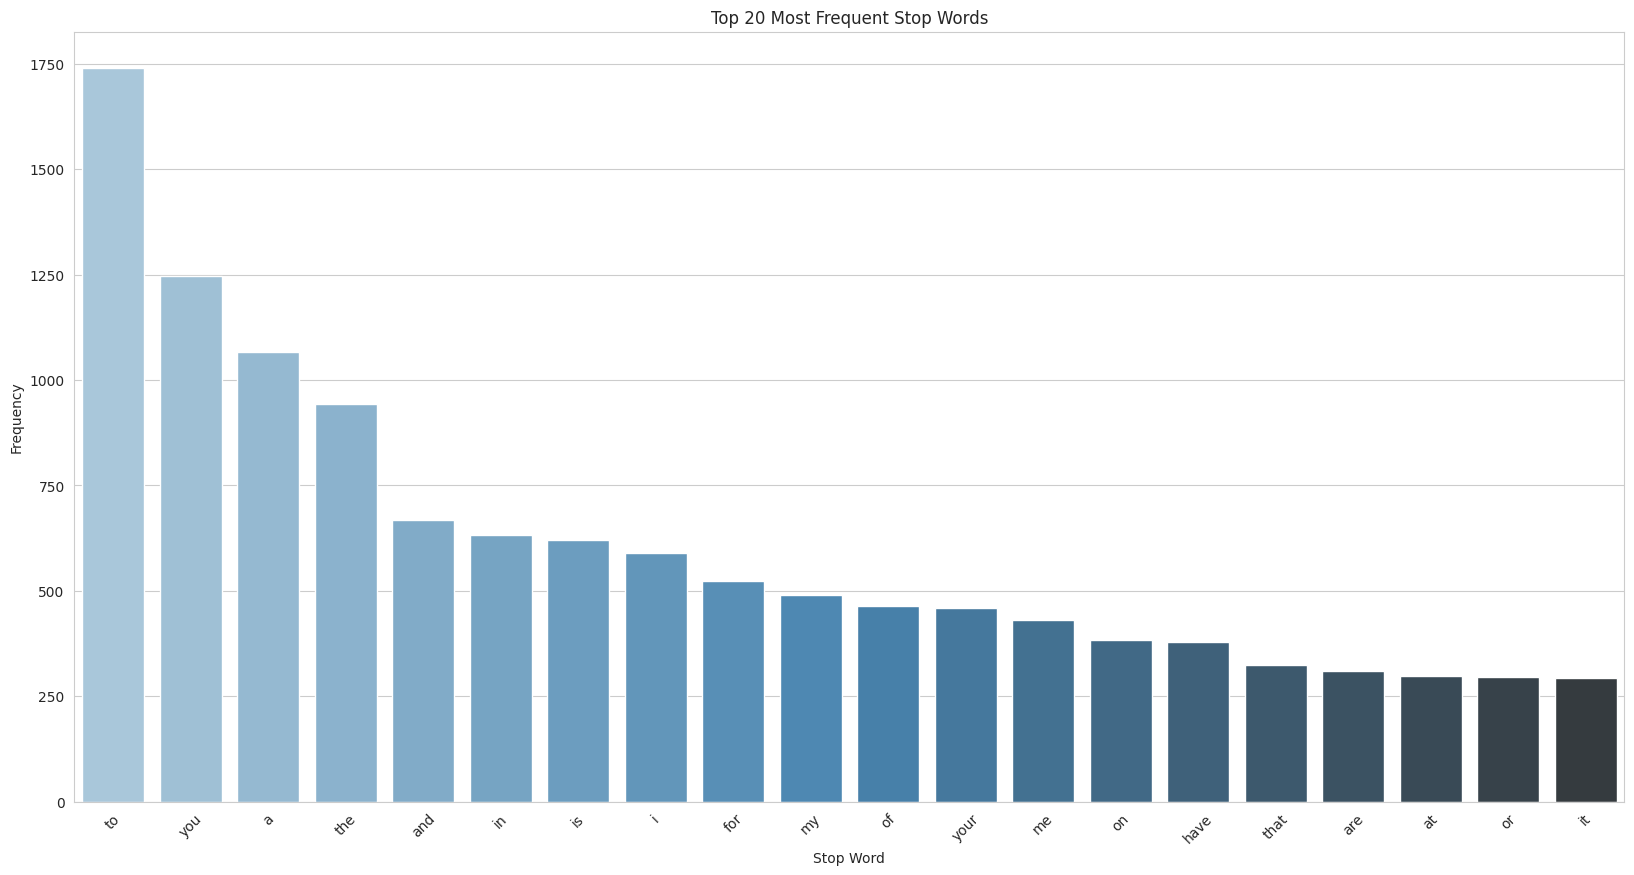

In [ ]:
def extract_stopwords_and_count(text):
    stop_words = set(stopwords.words('english'))  
    words = text.split()
    stopwords_in_text = [word for word in words if word in stop_words]
    word_counts = {}
    for word in stopwords_in_text:
        word_counts[word] = word_counts.get(word, 0) + 1
    return word_counts

train['stopword_counts'] = train['Text'].apply(extract_stopwords_and_count)
all_stopword_counts = []
for counts in train['stopword_counts']:
    all_stopword_counts.extend(list(counts.items()))
stopword_df = pd.DataFrame(all_stopword_counts, columns=['word', 'count'])

top_20_stopwords = stopword_df.groupby('word')['count'].sum().sort_values(ascending=False).head(20)

plt.figure(figsize=(20, 10))
sns.barplot(x=top_20_stopwords.index, y=top_20_stopwords.values, palette='Blues_d')
plt.xlabel('Stop Word')
plt.ylabel('Frequency')
plt.title('Top 20 Most Frequent Stop Words')
plt.xticks(rotation=45)
plt.show()

In [16]:
train.drop(['stopword_counts'],axis=1,inplace=True)
train

,Label,Text
1978,Not spam,No I'm in the same boat. Still here at my moms...
3989,Spam,(Bank of Granite issues Strong-Buy) EXPLOSIVE ...
3935,Not spam,They r giving a second chance to rahul dengra.
4078,Not spam,O i played smash bros &lt;#&gt; religiously.
4086,Spam,PRIVATE! Your 2003 Account Statement for 07973...
...,...,...
3772,Not spam,I came hostel. I m going to sleep. Plz call me...
5191,Not spam,"Sorry, I'll call later"
5226,Not spam,Prabha..i'm soryda..realy..frm heart i'm sory
5390,Not spam,Nt joking seriously i told


The most frequent tokens are common English stop words (e.g., to, you, a, the, and). This confirms that a subsequent preprocessing step to remove these stop words is necessary to ensure the model focuses on the more semantically distinct words shown in the word cloud (like FREE or URGENT).

# Features Engineering

## Features and Target Labels Split

In supervised learning, the data must be separated into Features ($\mathbf{X}$), which are the independent variables used for prediction (the Text column), and the Target ($\mathbf{y}$), which is the dependent variable we aim to predict (the Label column: 'Spam' or 'Not spam').The code correctly separates `x_train/x_test` (the text) from `y_train/y_test` (the labels).

In [ ]:
x_train = train.drop('Label', axis=1) 
y_train = train['Label'] 
x_test = test.drop('Label', axis=1) 
y_test = test['Label'] 

print("X_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (4457, 1)
y_train shape: (4457,)
X_test shape: (1115, 1)
y_test shape: (1115,)


## Data Cleaning

Text cleaning is vital to reduce noise and standardize the text, ensuring the model focuses on semantically relevant words.

**Contraction Expansion (`contractions.fix`):**

- Contractions (e.g., "I'm," "don't") need to be expanded to their full forms ("I am," "do not") before tokenization. If not expanded, "don't" might be treated as a single, unique token, losing the semantic contribution of "do" and "not."

**Special Character Removal (`remove_special_chars`):**

- Noise Reduction. Emojis, punctuation (?, !, ,), and non-ASCII characters add noise without improving classification accuracy in most basic models. Removing them simplifies the vocabulary and prevents the model from wasting capacity learning irrelevant characters. The text is also lowercased to ensure "The" and "the" are treated as the same word.

**Tokenization (`word_tokenize`):**

- Tokenization is the process of breaking down a string of text into smaller units called tokens (usually words or punctuation marks). It's the first step in converting raw text into a sequence the model can process.

**Stop Word Removal (`remove_stopwords`):**

- Vocabulary Reduction. As confirmed in the EDA, high-frequency, low-meaning words (stop words) are removed. This significantly reduces the size of the vocabulary, making the feature representation more efficient and often improving predictive power.

**Lemmatization (`WordNetLemmatizer`):**

- Stemming/Lemmatization. This process reduces different inflected forms of a word to a common base or root word (the lemma). For example, "running," "ran," and "runs" are all reduced to "run." This reduces feature redundancy and increases the chances that the model recognizes semantic connections between similar words.

In [ ]:
print("X_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

def remove_special_chars(text):
    emoji_pattern = re.compile(
        "["
        u"\U0001F600-\U0001F64F"
        u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF"
        u"\U0001F1E0-\U0001F1FF"
        "]+",
        flags=re.UNICODE
    )
    text = emoji_pattern.sub(r'', text)
    
    text = text.encode('ascii', 'ignore').decode('ascii')
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = text.lower().strip()
    return text

def tokenize_text(text):
    if isinstance(text, str):
        return word_tokenize(text)
    else:
        return []

def remove_stopwords(tokens):
    stop_words = set(stopwords.words('english'))
    if isinstance(tokens, list):
        return [word for word in tokens if word not in stop_words]
    else:
        return []

def lemmatize_tokens(tokenized_list):
    lemmatizer = WordNetLemmatizer()
    if isinstance(tokenized_list, list):
        return [lemmatizer.lemmatize(word) for word in tokenized_list]
    else:
        return []

def preprocess_text_pipeline(text):
    if not isinstance(text, str) or pd.isna(text):
        return ""

    expanded_text = contractions.fix(text)

    cleaned_text = remove_special_chars(expanded_text)

    tokens = tokenize_text(cleaned_text)

    tokens_without_stopwords = remove_stopwords(tokens)

    lemmas = lemmatize_tokens(tokens_without_stopwords)

    return " ".join(lemmas)

print("--- Sample before preprocessing ---")
print(x_train['Text'].iloc[0])

print("\n--- Applying preprocessing to X_train and X_test ---\n")

x_train_p = x_train['Text'].apply(preprocess_text_pipeline).to_frame()
x_test_p = x_test['Text'].apply(preprocess_text_pipeline).to_frame()

print("--- Sample after preprocessing (X_train) ---")
print(x_train_p.iloc[0])

print("\n--- Preprocessed X_train head ---")
print(x_train_p.head())

print("\n--- Preprocessed X_test head ---")
print(x_test_p.head())

print("\n--- Shapes after preprocessing ---")
print("x_train_p shape:", x_train_p.shape)
print("x_test_p shape:", x_test_p.shape)

X_train shape: (4457, 1)
y_train shape: (4457,)
X_test shape: (1115, 1)
y_test shape: (1115,)
--- Sample before preprocessing ---
No I'm in the same boat. Still here at my moms. Check me out on yo. I'm half naked.

--- Applying preprocessing to X_train and X_test ---

--- Sample after preprocessing (X_train) ---
Text    boat still mom check yo half naked
Name: 1978, dtype: object

--- Preprocessed X_train head ---
                                                   Text
1978                 boat still mom check yo half naked
3989  bank granite issue strongbuy explosive pick me...
3935                r giving second chance rahul dengra
4078                 played smash bros ltgt religiously
4086  private 2003 account statement 07973788240 sho...

--- Preprocessed X_test head ---
                                                   Text
3245  funny fact nobody teach volcano 2 erupt tsunam...
944   sent score sophas secondary application school...
1044  know someone know fancy call 090580972

In [19]:
x_train = x_train_p.copy()
x_test = x_test_p.copy()

## Target Labels Encoding

Machine learning models, particularly traditional algorithms like Logistic Regression or Support Vector Machines, cannot directly process text labels ('Spam', 'Not spam'). They require numerical input. Label Encoding converts categorical labels into numerical integers.The results show: 'Not spam' $\to 0$ and 'Spam' $\to 1$. This simple binary mapping is necessary for training the classification model.

In [20]:
le = LabelEncoder()
le.fit(y_train)
y_train = le.transform(y_train)
y_test = le.transform(y_test)
y_train

array([0, 1, 0, ..., 0, 0, 0])

In [ ]:
print("\n--- Original Class to Encoded Value Mapping ---")
for original_class, encoded_value in zip(le.classes_, le.transform(le.classes_)):
    print(f"'{original_class}' -> {encoded_value}")
print("-" * 30)


--- Original Class to Encoded Value Mapping ---
'Not spam' -> 0
'Spam' -> 1
------------------------------


## Text Representation (TF-IDF)

Vectorization : Machine learning models operate on numerical vectors. Text Vectorization is the process of converting cleaned text into a matrix of numerical features.

**TF-IDF (Term Frequency-Inverse Document Frequency)**

- **Term Frequency (TF)**: How often a word appears in a specific document (SMS message).
- **Inverse Document Frequency (IDF)**: Measures how rare the word is across the entire corpus. Words that appear in many documents (like "the") get a lower IDF score, while rare, highly specific words get a higher score.
- **Combined Feature**: The TF-IDF score for a word in a document is the product of TF and IDF. This weighting scheme favors words that are frequent in a specific message (high TF) but rare across the entire dataset (high IDF), making them strong distinguishing features (e.g., specific phone numbers, phrases like "URGENT claim").

In [ ]:
x_train = x_train['Text'].astype(str).tolist()
x_test = x_test['Text'].astype(str).tolist()

tfidf_vectorizer = TfidfVectorizer(max_features=40) 

x_train_tfidf = tfidf_vectorizer.fit_transform(x_train)
x_test_tfidf = tfidf_vectorizer.transform(x_test)

x_train_tfidf = x_train_tfidf.toarray()
x_test_tfidf = x_test_tfidf.toarray()

x_train_tfidf

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [23]:
x_train = x_train_tfidf.copy()
x_test = x_test_tfidf.copy()

## Oversampling (ADASYN)

The initial data split showed severe class imbalance (Not spam $\approx 86.6\%$, Spam $\approx 13.4\%$). Oversampling can mitigate model bias toward the majority class, oversampling artificially increases the number of samples in the minority class.

**ADASYN (Adaptive Synthetic Sampling)**

This is a sophisticated oversampling technique that focuses on generating synthetic minority samples near the decision boundary. Unlike simple duplication, ADASYN creates new, synthetic samples by interpolating between existing minority samples, especially those that are harder to classify (i.e., near the majority class).This helps smooth the decision boundary and prevents overfitting to a few duplicated examples.


Class distribution in y_train BEFORE ADASYN:
0    86.60534
1    13.39466
Name: proportion, dtype: float64


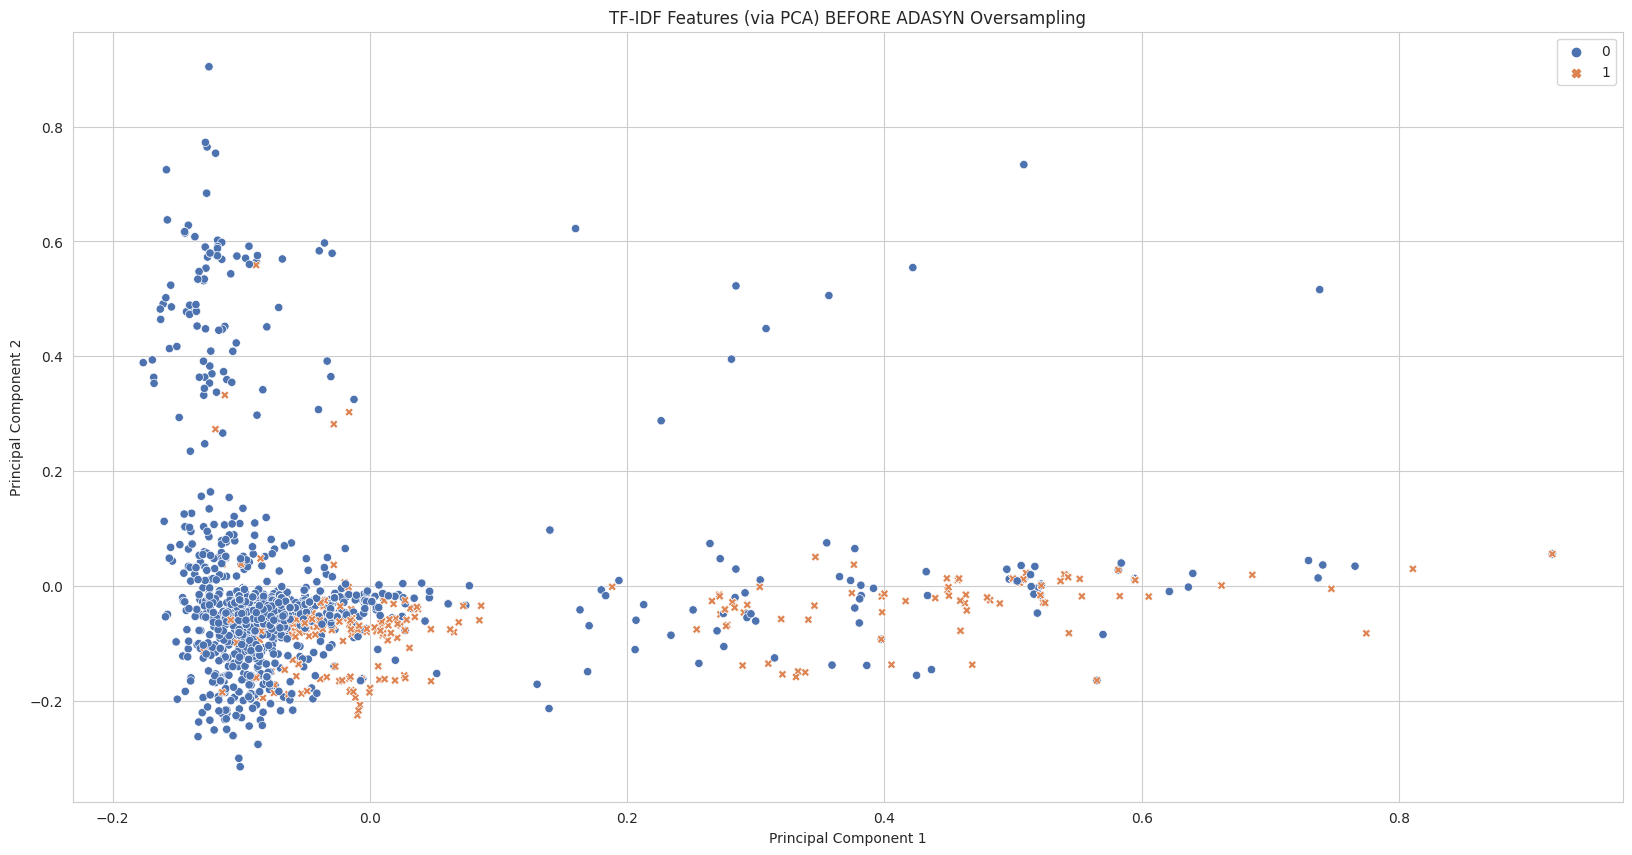

In [ ]:
print("\nClass distribution in y_train BEFORE ADASYN:")
print(pd.Series(y_train).value_counts(normalize=True) * 100)

pca = PCA(n_components=2, random_state=42)
x_train_pca = pca.fit_transform(x_train_tfidf)

plt.figure(figsize=(20, 10))
sns.scatterplot(
    x=x_train_pca[:, 0],
    y=x_train_pca[:, 1],
    hue=y_train,
    style=y_train,
    palette='deep'
)
plt.title('TF-IDF Features (via PCA) BEFORE ADASYN Oversampling')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
adasyn = ADASYN(sampling_strategy='minority', random_state=42)

x_train_resampled, y_train_resampled = adasyn.fit_resample(x_train_tfidf, y_train)


Class distribution in y_train AFTER ADASYN:
1    50.251321
0    49.748679
Name: proportion, dtype: float64


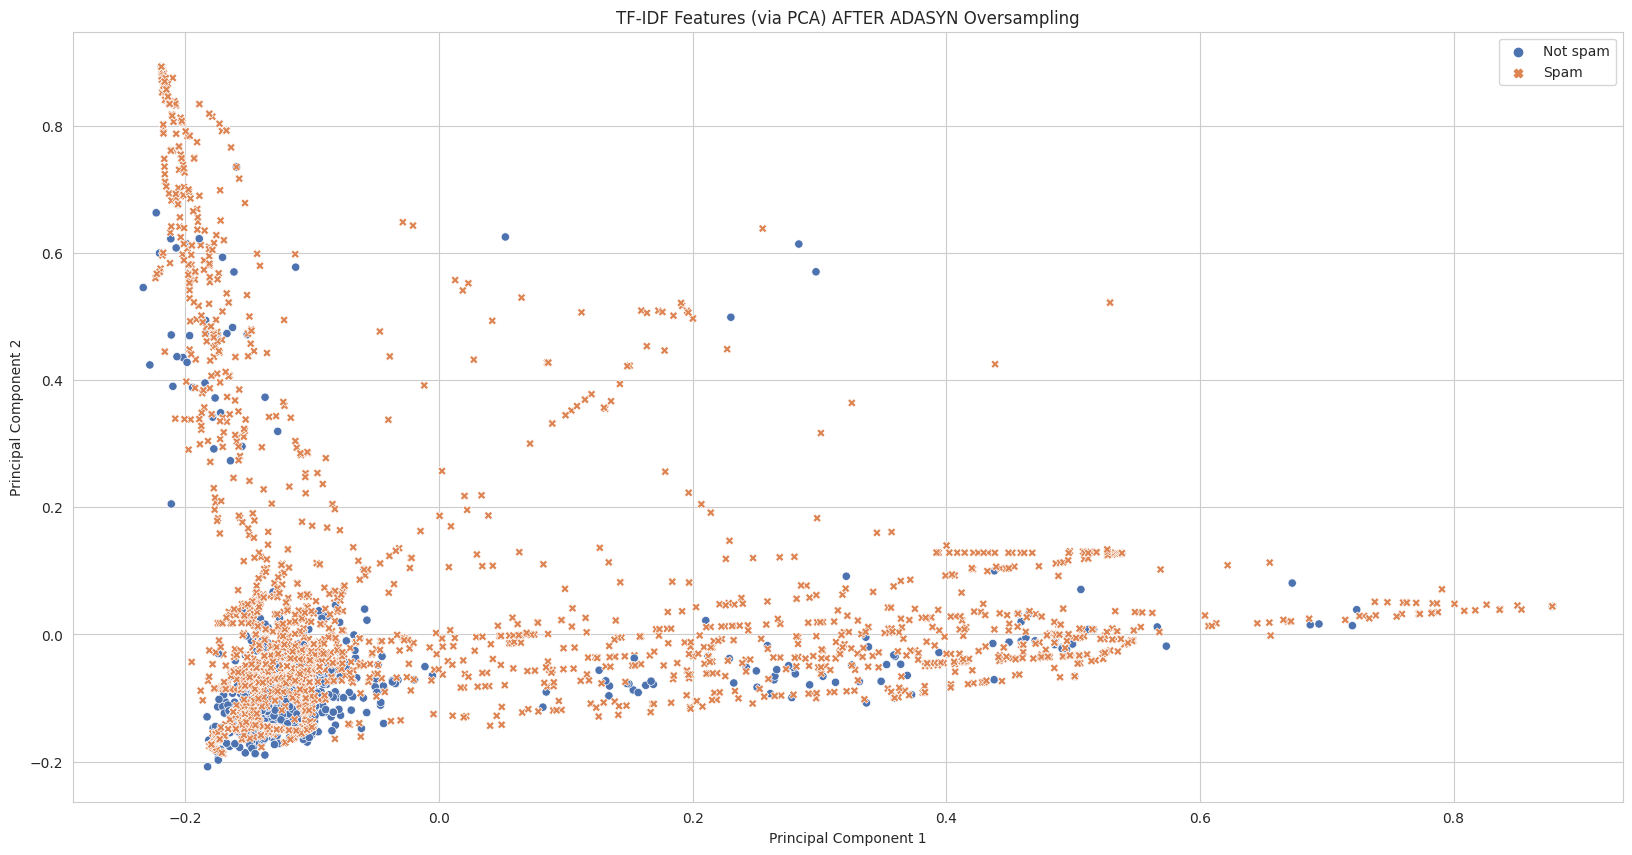

In [ ]:
print("\nClass distribution in y_train AFTER ADASYN:")
print(pd.Series(y_train_resampled).value_counts(normalize=True) * 100)

x_train_resampled_pca = pca.fit_transform(x_train_resampled)

plt.figure(figsize=(20, 10))
sns.scatterplot(
    x=x_train_resampled_pca[:, 0],
    y=x_train_resampled_pca[:, 1],
    hue=pd.Series(y_train_resampled).map(dict(enumerate(le.classes_))),
    style=pd.Series(y_train_resampled).map(dict(enumerate(le.classes_))),
    palette='deep'
)
plt.title('TF-IDF Features (via PCA) AFTER ADASYN Oversampling')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

In [27]:
x_train = x_train_resampled
y_train = y_train_resampled

## Dimensionality Reduction (PCA)

PCA (Principal Component Analysis). This is a linear dimensionality reduction technique used here for visualization. It projects high-dimensional data (in this case, 40 TF-IDF features) onto a lower-dimensional subspace (2 components) while retaining as much variance (information) as possible.

While the model will likely use the full 40 features for training, PCA is used post-ADASYN to visualize how the newly generated synthetic samples affect the feature space.

In [ ]:
pca = PCA(n_components=2, random_state=42)
x_train = pca.fit_transform(x_train_resampled)
x_test = pca.transform(x_test)

print("\n--- Shapes after preprocessing ---")
print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)


--- Shapes after preprocessing ---
x_train shape: (7759, 2)
x_test shape: (1115, 2)


# Model Training

## Weak Learner Model Selection

Model Building: This involves selecting algorithms designed to learn the relationship between the input features ($\mathbf{X}$, the TF-IDF vectors) and the target variable ($\mathbf{y}$, the Spam/Not spam label). The goal is to find a function that can predict the label for unseen text.

**Cross-Validation (K-Fold)**

Cross-validation is a crucial technique for robust model evaluation. Instead of splitting the training data once into a single train/validation set, K-Fold splits the data into $K$ equally sized, non-overlapping subsets (here, $K=5$ folds).
- Process: The model is trained $K$ times. In each iteration, one fold is reserved as the validation set, and the remaining $K-1$ folds are used for training.
- Benefit: This ensures that every data point is used exactly once for validation and $K-1$ times for training, providing a much more reliable estimate of the model's true performance (generalization error) than a single train/test split. The average accuracy across the $K$ folds is the final metric.

**Model Testing and Selection**

The code tests a variety of machine learning paradigms:
- Linear Models: Logistic Regression (LR) models the probability of a binary outcome using a sigmoid function and is highly effective for linearly separable text data.
- Distance-Based Models: K-Nearest Neighbors (KNN) classifies a point based on the majority class of its $K$ nearest neighbors in the feature space.Tree-Based Models: Decision Tree (DT) creates a flowchart-like structure to arrive at a decision.
- Ensemble Models (Boosting and Bagging):
    - Random Forest Classifier (Bagging): Builds multiple Decision Trees on bootstrap samples of the data and averages their predictions to reduce variance and prevent overfitting.
    - Gradient Boosting Machines (XGBoost, LightGBM, CatBoost): These are powerful boosting techniques. They sequentially build decision trees, where each new tree corrects the errors (residuals) of the previous ones, focusing on misclassified samples. They are renowned for high performance.

In [ ]:
ml_models = [
    ('Logistic Regression', LogisticRegression(max_iter=1000)),
    ("KNN", KNeighborsClassifier()),
    ("Decision Tree", DecisionTreeClassifier()),
    ("Random Forest Classifier", RandomForestClassifier()),
    ("XGBoost", XGBClassifier(eval_metric='logloss')), 
    ("LightGBM", LGBMClassifier(verbose=-1)),
    ("CatBoost", CatBoostClassifier(verbose=0))
]

results = []
model_names = []

print("Starting cross-validation on the oversampled training data...\n")

for model_name, model in ml_models:
    print(f'{model_name}:')
    try:
        cv_scores = cross_val_score(model, x_train, y_train, cv=5, scoring='accuracy')

        print(f'\tK-Fold Cross-Validation Scores: {np.round(cv_scores, 4)}')
        print('-' * 100)
        print(f'\tAverage K-Fold Cross-Validation Accuracy: {np.round(cv_scores.mean(), 4)}\n')

        results.append(cv_scores)
        model_names.append(model_name)
    except Exception as e:
        print(f'\tError occurred during cross-validation for {model_name}: {str(e)}')
        print('-' * 100)
        results.append(np.array([np.nan] * 5))  
        model_names.append(model_name)

print("---------------- FINAL SUMMARY ----------------")
for i, name in enumerate(model_names):
    mean_score = np.round(np.nanmean(results[i]), 4) if not np.all(np.isnan(results[i])) else "N/A"
    print(f"{name:<25} | Avg Accuracy: {mean_score}")
print("-----------------------------------------------")

Starting cross-validation on the oversampled training data...

Logistic Regression:
	K-Fold Cross-Validation Scores: [0.7326 0.7236 0.7146 0.6991 0.6757]
----------------------------------------------------------------------------------------------------
	Average K-Fold Cross-Validation Accuracy: 0.7091

KNN:
	K-Fold Cross-Validation Scores: [0.7732 0.7919 0.7751 0.7146 0.7331]
----------------------------------------------------------------------------------------------------
	Average K-Fold Cross-Validation Accuracy: 0.7576

Decision Tree:
	K-Fold Cross-Validation Scores: [0.8183 0.8351 0.7957 0.797  0.7937]
----------------------------------------------------------------------------------------------------
	Average K-Fold Cross-Validation Accuracy: 0.808

Random Forest Classifier:
	K-Fold Cross-Validation Scores: [0.8273 0.8396 0.8086 0.8099 0.8079]
----------------------------------------------------------------------------------------------------
	Average K-Fold Cross-Validation A

<style type="text/css">
.tg  {border-collapse:collapse;border-spacing:0;}
.tg td{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  overflow:hidden;padding:10px 5px;word-break:normal;}
.tg th{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  font-weight:normal;overflow:hidden;padding:10px 5px;word-break:normal;}
.tg .tg-2b7s{text-align:right;vertical-align:bottom}
.tg .tg-k9u1{border-color:inherit;color:#1B1C1D;font-size:100%;text-align:left;vertical-align:bottom}
.tg .tg-7zrl{text-align:left;vertical-align:bottom}
.tg .tg-0lax{text-align:left;vertical-align:top}
</style>
<table class="tg"><thead>
  <tr>
    <th class="tg-k9u1">Model</th>
    <th class="tg-7zrl">Average K-Fold Cross-Validation Accuracy</th>
    <th class="tg-7zrl">Interpretation</th>
  </tr></thead>
<tbody>
  <tr>
    <td class="tg-7zrl">Random Forest</td>
    <td class="tg-2b7s">0.8187</td>
    <td class="tg-0lax">The highest-performing single model, benefiting from bagging to reduce the variance of individual decision trees.</td>
  </tr>
  <tr>
    <td class="tg-7zrl">XGBoost</td>
    <td class="tg-2b7s">0.8114</td>
    <td class="tg-0lax">Strong performance, typical of boosting algorithms that sequentially correct errors.</td>
  </tr>
  <tr>
    <td class="tg-7zrl">LightGBM</td>
    <td class="tg-2b7s">0.809</td>
    <td class="tg-0lax">Similar to XGBoost, a fast and efficient gradient boosting method.</td>
  </tr>
  <tr>
    <td class="tg-7zrl">Decision Tree</td>
    <td class="tg-2b7s">0.808</td>
    <td class="tg-0lax">Solid base performance, but often benefits from ensemble methods.</td>
  </tr>
  <tr>
    <td class="tg-7zrl">CatBoost</td>
    <td class="tg-2b7s">0.8069</td>
    <td class="tg-0lax">Another robust boosting method, known for handling categorical features well (though less relevant here with pure numerical TF-IDF features).</td>
  </tr>
  <tr>
    <td class="tg-7zrl">KNN</td>
    <td class="tg-2b7s">0.7576</td>
    <td class="tg-0lax">Lower performance suggests that proximity in the TF-IDF feature space alone is not the most effective separation mechanism.</td>
  </tr>
  <tr>
    <td class="tg-7zrl">Logistic Regression</td>
    <td class="tg-2b7s">0.7091</td>
    <td class="tg-0lax">The lowest accuracy. This suggests the data, even after TF-IDF vectorization, is not linearly separable in the 40-dimensional feature space, or that 40 features are insufficient for a linear model to capture complex boundaries.</td>
  </tr>
</tbody></table>

Ensemble methods (Random Forest and XGBoost) clearly outperform the simpler models (LR and KNN), confirming that complex, non-linear boundaries are required to classify Spam/Not spam accurately in this dataset.

## Decision Boundary Visualization (Weak Learner)

**Decision Boundary:**

- Concept: A decision boundary is the line, surface, or hyperplane that separates the data points of different classes (Spam vs. Not spam) in the feature space.
- Interpretation: The complexity and shape of the boundary directly reflect the model's complexity. A straight line indicates a linear model (like Logistic Regression), while wavy or nested shapes indicate non-linear, flexible models (like Decision Trees or Random Forests). Since the original TF-IDF data had 40 dimensions, the models were plotted using the 2 Principal Components (PC1 and PC2) created during the dimensionality reduction phase. While the models were trained on the full 40 features, plotting the boundaries in the 2D PCA space helps visualize their general approach to classification .

Fitting Logistic Regression model...
Plotting decision boundary for Logistic Regression...
Fitting KNN model...
Plotting decision boundary for KNN...
Fitting Decision Tree model...
Plotting decision boundary for Decision Tree...
Fitting Random Forest Classifier model...
Plotting decision boundary for Random Forest Classifier...
Fitting XGBoost model...
Plotting decision boundary for XGBoost...
Fitting LightGBM model...
Plotting decision boundary for LightGBM...
Fitting CatBoost model...
Plotting decision boundary for CatBoost...


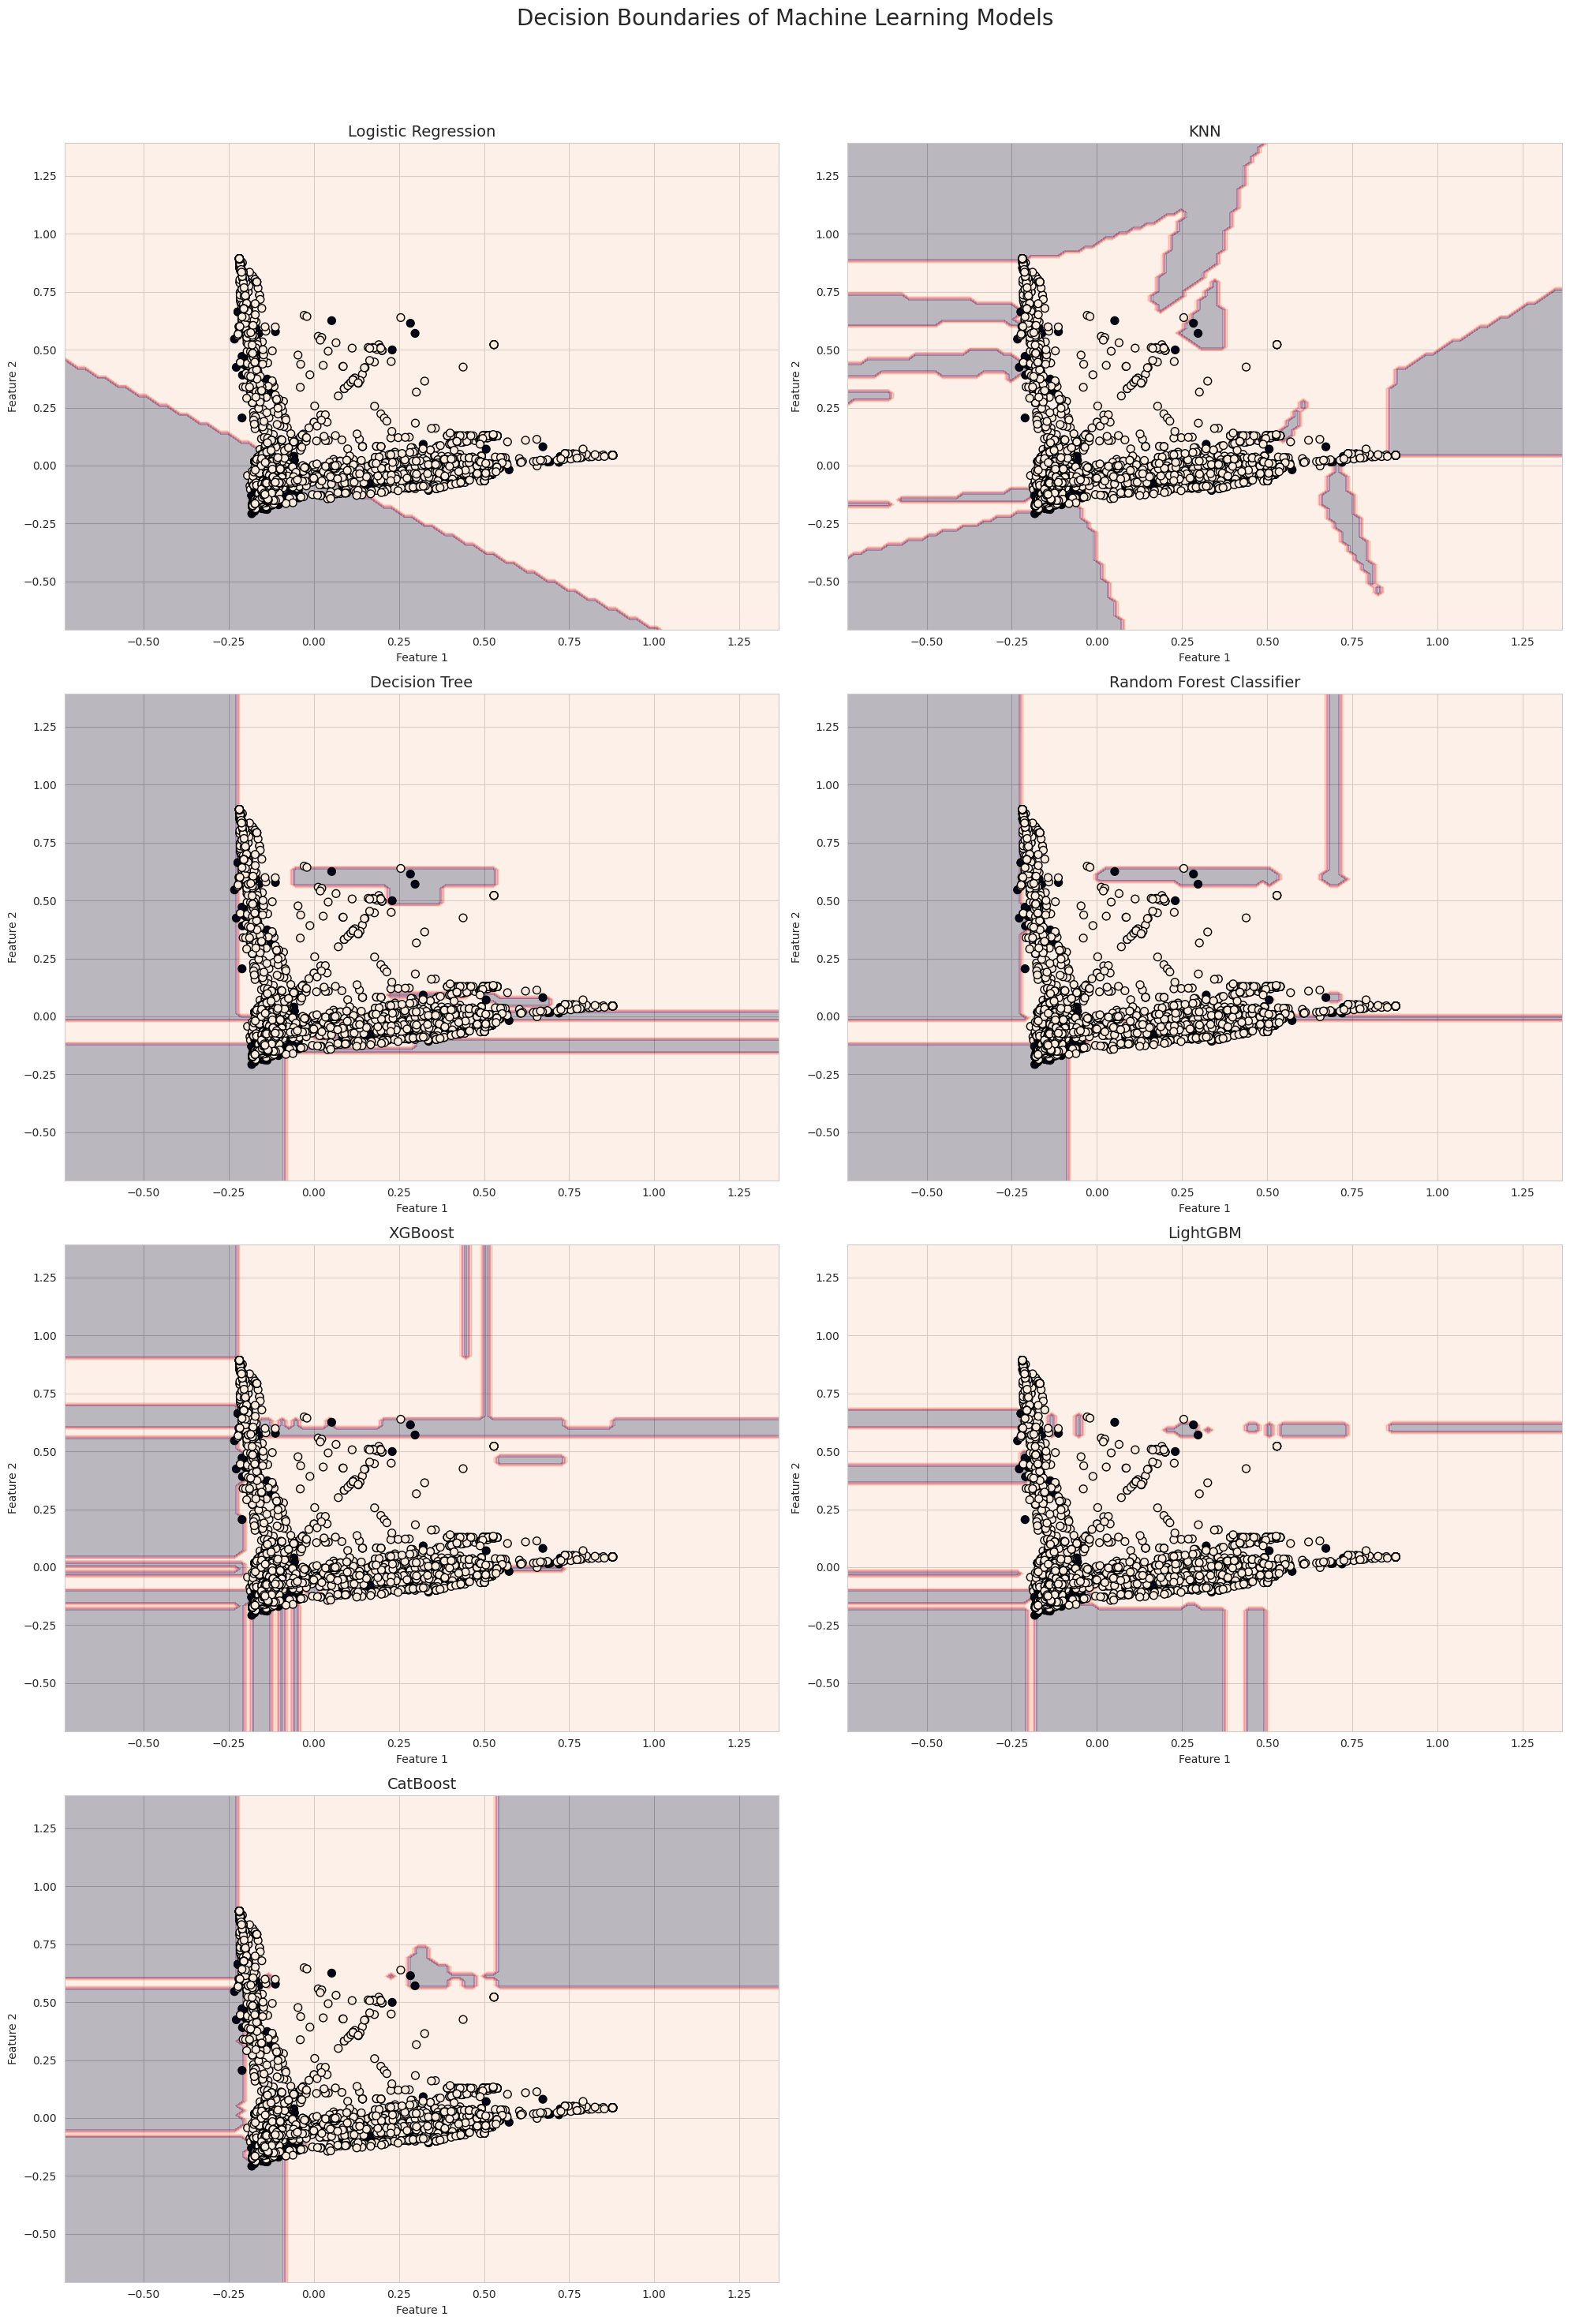


Plotting complete. Check the displayed window for the decision boundaries.


In [ ]:
ml_models = [
    ('Logistic Regression', LogisticRegression(max_iter=1000)),
    ("KNN", KNeighborsClassifier()),
    ("Decision Tree", DecisionTreeClassifier()),
    ("Random Forest Classifier", RandomForestClassifier()),
    ("XGBoost", XGBClassifier(eval_metric='logloss')), 
    ("LightGBM", LGBMClassifier(verbose=-1)),
    ("CatBoost", CatBoostClassifier(verbose=0))
]

def plot_decision_boundary(model, X_train, y_train, ax, title):
    x_min, x_max = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
    y_min, y_max = X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.3)
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=50, edgecolor='k')
    
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

fig, axes = plt.subplots(4, 2, figsize=(20, 30))
fig.suptitle('Decision Boundaries of Machine Learning Models', fontsize=20)
axes = axes.flatten()

for i, (name, model) in enumerate(ml_models):
    print(f"Fitting {name} model...")
    model.fit(x_train, y_train)
    print(f"Plotting decision boundary for {name}...")
    plot_decision_boundary(model, x_train, y_train, axes[i], name)

axes[-1].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print("\nPlotting complete. Check the displayed window for the decision boundaries.")

- Logistic Regression: Displays a relatively straight or smooth boundary, which is characteristic of a linear model attempting to find the single best hyperplane to separate the two classes.
- KNN: Shows a highly irregular, piece-wise boundary that conforms closely to the nearest training data points. This is typical of a non-parametric, instance-based model.
- Decision Tree: Shows boundaries that consist of horizontal and vertical line segments, reflecting its process of splitting the feature space based on single feature thresholds. This highlights the rectangular segmentation property of tree-based models.
- Random Forest, XGBoost, LightGBM, CatBoost (Boosting Models): Their boundaries are smoother and more complex than the single Decision Tree, yet they capture intricate non-linear shapes. This smoothness comes from the aggregation of many individual trees (the ensemble effect).

## Ensemble Model Selection

Ensemble Learning is a powerful meta-algorithm that combines the predictions of several base estimators to improve robustness and accuracy over any single estimator.

- Voting Classifier (`voting='soft'`): The soft voting classifier combines predictions by averaging the predicted class probabilities ($\mathbf{P}(\text{class} | \mathbf{X})$) from each base model. The final prediction is the class with the highest average probability.
    - Benefit: By averaging probabilities, it reduces the risk of one poorly performing model skewing the result and is generally more robust than hard (majority) voting.

- Stacking Classifier: Stacking is a multi-layer ensemble.
    - Layer 1 (Base Estimators): The base models (XGBoost, LightGBM, etc.) are trained on the data.
    - Layer 2 (Meta-Estimator): The predictions of the base models become the input features for a final model (the `final_estimator`, here a Random Forest).
    - Benefit: This allows the meta-model to learn the optimal way to combine and weigh the predictions of the diverse base models, potentially uncovering complex interactions between their output.

In [ ]:
es_models = [
    ("Voting", VotingClassifier(estimators=[
        ("Random Forest Classifier", RandomForestClassifier()),
        ("XGBoost", XGBClassifier(n_jobs=-1)),
        ("LightGBM", LGBMClassifier(verbose=-1)),
        ("CatBoost", CatBoostClassifier(verbose=0)),
        ("Decision Tree", DecisionTreeClassifier())
    ], n_jobs=-1, voting='soft')),
    ("Stacking", StackingClassifier(final_estimator=RandomForestClassifier(), estimators=[
        ("XGBoost", XGBClassifier(n_jobs=-1)),  # Unique name
        ("LightGBM", LGBMClassifier(verbose=-1)),
        ("CatBoost", CatBoostClassifier(verbose=0)),
        ("Decision Tree", DecisionTreeClassifier())
    ], n_jobs=-1))
]

results = []
model_names = []

print("Starting cross-validation on the oversampled training data...\n")

for model_name, model in es_models:
    print(f'{model_name}:')
    try:
        cv_scores = cross_val_score(model, x_train, y_train, cv=5, scoring='accuracy')

        print(f'\tK-Fold Cross-Validation Scores: {np.round(cv_scores, 4)}')
        print('-' * 100)
        print(f'\tAverage K-Fold Cross-Validation Accuracy: {np.round(cv_scores.mean(), 4)}\n')

        results.append(cv_scores)
        model_names.append(model_name)
    except Exception as e:
        print(f'\tError occurred during cross-validation for {model_name}: {str(e)}')
        print('-' * 100)
        results.append(np.array([np.nan] * 5))  
        model_names.append(model_name)

print("---------------- FINAL SUMMARY ----------------")
for i, name in enumerate(model_names):
    mean_score = np.round(np.nanmean(results[i]), 4) if not np.all(np.isnan(results[i])) else "N/A"
    print(f"{name:<25} | Avg Accuracy: {mean_score}")
print("-----------------------------------------------")

Starting cross-validation on the oversampled training data...

Voting:
	K-Fold Cross-Validation Scores: [0.8293 0.8486 0.8073 0.8048 0.8066]
----------------------------------------------------------------------------------------------------
	Average K-Fold Cross-Validation Accuracy: 0.8193

Stacking:


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/ut

	K-Fold Cross-Validation Scores: [0.8273 0.8351 0.7977 0.7854 0.7498]
----------------------------------------------------------------------------------------------------
	Average K-Fold Cross-Validation Accuracy: 0.7991

---------------- FINAL SUMMARY ----------------
Voting                    | Avg Accuracy: 0.8193
Stacking                  | Avg Accuracy: 0.7991
-----------------------------------------------


<style type="text/css">
.tg  {border-collapse:collapse;border-spacing:0;}
.tg td{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  overflow:hidden;padding:10px 5px;word-break:normal;}
.tg th{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  font-weight:normal;overflow:hidden;padding:10px 5px;word-break:normal;}
.tg .tg-2b7s{text-align:right;vertical-align:bottom}
.tg .tg-k9u1{border-color:inherit;color:#1B1C1D;font-size:100%;text-align:left;vertical-align:bottom}
.tg .tg-7zrl{text-align:left;vertical-align:bottom}
.tg .tg-0lax{text-align:left;vertical-align:top}
</style>
<table class="tg"><thead>
  <tr>
    <th class="tg-k9u1">Model</th>
    <th class="tg-7zrl">Average K-Fold Cross-Validation Accuracy</th>
    <th class="tg-0lax">Change from Best Single Model (RF: 0.8187)</th>
  </tr></thead>
<tbody>
  <tr>
    <td class="tg-7zrl">Voting</td>
    <td class="tg-2b7s">0.8193</td>
    <td class="tg-0lax">Slightly higher (0.0006)</td>
  </tr>
  <tr>
    <td class="tg-7zrl">Stacking</td>
    <td class="tg-2b7s">0.7991</td>
    <td class="tg-0lax">Noticeably lower (0.0196)</td>
  </tr>
</tbody>
</table>

While the single Random Forest Classifier ($\mathbf{0.8187}$) was the highest performing single model, the Voting Classifier ($\mathbf{0.8193}$) achieved the best overall performance. The small improvement ($\mathbf{ 0.0006}$) suggests that:

- The predictive power is maximized by the Voting Classifier.
- Averaging the probabilities of the selected strong base models (Voting) provides a slight but real improvement over the best individual model, confirming the benefit of soft voting ensemble methods.
- The Stacking Classifier performed worse, indicating that the $\text{final\_estimator}$ (Random Forest) struggled to learn an effective combination function from the base models' predictions with the current parameters.

## Decision Boundary (Ensemble Model)

Fitting Voting model...
Plotting decision boundary for Voting...
Fitting Stacking model...


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Plotting decision boundary for Stacking...


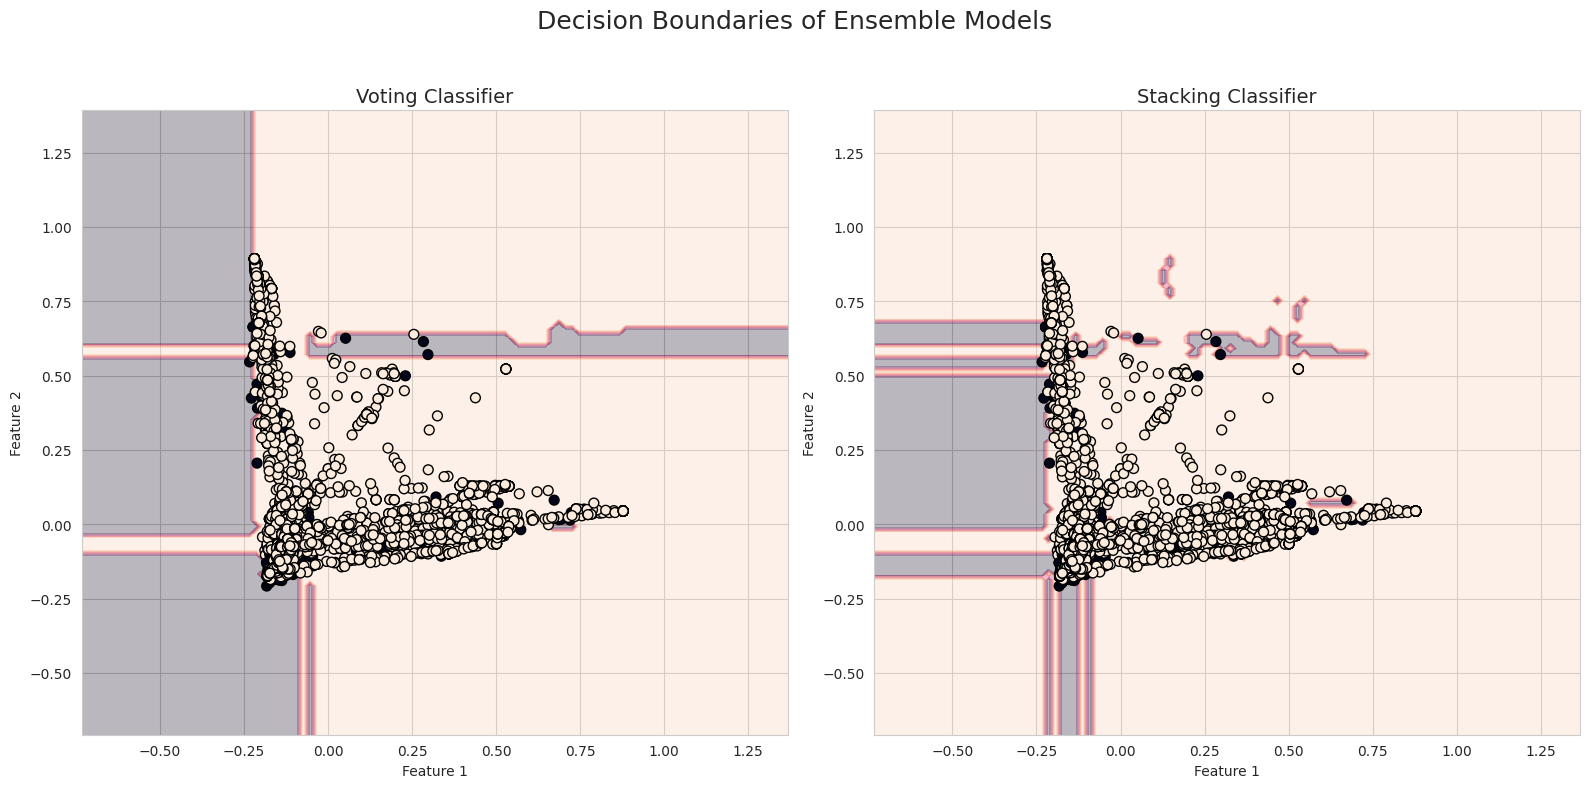


Plotting complete. Check the displayed window for the decision boundaries.


In [ ]:
es_models = [
    ("Voting", VotingClassifier(estimators=[
        ("Random Forest Classifier", RandomForestClassifier()),
        ("XGBoost", XGBClassifier(n_jobs=-1)),
        ("LightGBM", LGBMClassifier(verbose=-1)),
        ("CatBoost", CatBoostClassifier(verbose=0)),
        ("Decision Tree", DecisionTreeClassifier())
    ], n_jobs=-1, voting='soft')),
    ("Stacking", StackingClassifier(final_estimator=RandomForestClassifier(), estimators=[
        ("XGBoost", XGBClassifier(n_jobs=-1)),  # Unique name
        ("LightGBM", LGBMClassifier(verbose=-1)),
        ("CatBoost", CatBoostClassifier(verbose=0)),
        ("Decision Tree", DecisionTreeClassifier())
    ], n_jobs=-1))
]

def plot_decision_boundary(model, X_train, y_train, ax, title):
    """
    Plots the decision boundary for a given model on a Matplotlib axis.

    Args:
        model (estimator): The trained scikit-learn model.
        X_train (np.array): The training data features.
        y_train (np.array): The training data labels.
        ax (matplotlib.axes.Axes): The axis to plot on.
        title (str): The title for the plot.
    """
    x_min, x_max = X_train[:, 0].min() - 0.5, X_train[:, 0].max() + 0.5
    y_min, y_max = X_train[:, 1].min() - 0.5, X_train[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3)
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, s=50, edgecolor='k')
    
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
fig.suptitle('Decision Boundaries of Ensemble Models', fontsize=18)

for i, (name, model) in enumerate(es_models):
    print(f"Fitting {name} model...")
    model.fit(x_train, y_train)
    print(f"Plotting decision boundary for {name}...")
    plot_decision_boundary(model, x_train, y_train, axes[i], f'{name} Classifier')

plt.tight_layout(rect=[0, 0, 1, 0.95]) 
plt.show()

print("\nPlotting complete. Check the displayed window for the decision boundaries.")

- Voting Classifier: The boundary is smooth, complex, and represents a consensus, largely resembling the aggregate of the best-performing tree-based models.
- Stacking Classifier: The boundary is visibly more intricate, as the meta-model (Random Forest) is attempting to draw a decision boundary based on the soft predictions of the base models.

## Hyperparameters Tuning (Optuna)

**Hyperparameter Tuning**

Hyperparameters are parameters whose values control the learning process and model structure (e.g., max_depth in a Decision Tree, learning_rate in XGBoost). They are not learned from the data. Tuning is the process of finding the combination of these values that yields the highest performance.

**Optuna**

Optuna is an automatic hyperparameter optimization framework that uses a search strategy called the Tree-structured Parzen Estimator (TPE). Unlike brute-force methods like Grid Search, Optuna intelligently chooses the next set of hyperparameters to test based on the performance of previous trials. This makes the search process much more efficient.
- Objective Function: The objective function serves as the interface for Optuna. It takes a trial object, suggests parameter values (e.g., trial.suggest_int, trial.suggest_float), builds the model (here, a Weighted Voting Classifier), and returns the cross-validation score.

**Weighted Voting**

The tuning here is sophisticated as it optimizes both the internal parameters of the base models and the relative weights given to each model's prediction in the final Voting Classifier. This aims to give higher influence to the base models that are more reliable for this specific task.

In [ ]:
def objective(trial):
    rf_params = {
        'n_estimators': trial.suggest_int('rf_n_estimators', 50, 200),
        'max_depth': trial.suggest_int('rf_max_depth', 5, 20),
        'min_samples_split': trial.suggest_float('rf_min_samples_split', 0.05, 1.0, log=True),
        'min_samples_leaf': trial.suggest_float('rf_min_samples_leaf', 0.01, 0.5, log=True),
        'random_state': 42
    }
    rf_clf = RandomForestClassifier(**rf_params)
    
    xgb_params = {
        'n_estimators': trial.suggest_int('xgb_n_estimators', 50, 200),
        'max_depth': trial.suggest_int('xgb_max_depth', 3, 10),
        'learning_rate': trial.suggest_float('xgb_learning_rate', 1e-4, 1e-1, log=True),
        'subsample': trial.suggest_float('xgb_subsample', 0.5, 1.0),
        'eval_metric': 'logloss',
        'n_jobs': -1,
        'random_state': 42
    }
    xgb_clf = XGBClassifier(**xgb_params)
    
    lgbm_params = {
        'n_estimators': trial.suggest_int('lgbm_n_estimators', 50, 200),
        'max_depth': trial.suggest_int('lgbm_max_depth', 5, 20),
        'learning_rate': trial.suggest_float('lgbm_learning_rate', 1e-4, 1e-1, log=True),
        'verbose': -1,
        'n_jobs': -1,
        'random_state': 42,
        'verbose': -1
    }
    lgbm_clf = LGBMClassifier(**lgbm_params)
    
    cat_params = {
        'iterations': trial.suggest_int('cat_iterations', 50, 200),
        'learning_rate': trial.suggest_float('cat_learning_rate', 1e-4, 1e-1, log=True),
        'verbose': 0,
        'random_state': 42
    }
    cat_clf = CatBoostClassifier(**cat_params)
    
    dt_params = {
        'max_depth': trial.suggest_int('dt_max_depth', 3, 15),
        'min_samples_split': trial.suggest_float('dt_min_samples_split', 0.05, 1.0, log=True),
        'min_samples_leaf': trial.suggest_float('dt_min_samples_leaf', 0.01, 0.5, log=True),
        'random_state': 42
    }
    dt_clf = DecisionTreeClassifier(**dt_params)
    
    estimators = [
        ("Random Forest Classifier", rf_clf),
        ("XGBoost", xgb_clf),
        ("LightGBM", lgbm_clf),
        ("CatBoost", cat_clf),
        ("Decision Tree", dt_clf)
    ]
    
    weights = [
        trial.suggest_float("weight_rf", 0.0, 1.0),
        trial.suggest_float("weight_xgb", 0.0, 1.0),
        trial.suggest_float("weight_lgbm", 0.0, 1.0),
        trial.suggest_float("weight_cat", 0.0, 1.0),
        trial.suggest_float("weight_dt", 0.0, 1.0)
    ]
    
    total_weight = sum(weights)
    normalized_weights = [w / total_weight if total_weight > 0 else 1/len(weights) for w in weights]
    
    voting_clf = VotingClassifier(
        estimators=estimators,
        voting='soft',
        weights=normalized_weights,
        n_jobs=-1
    )

    score = cross_val_score(voting_clf, x_train_resampled, y_train_resampled, cv=5, scoring='accuracy', n_jobs=-1)
    
    return score.mean()

study = optuna.create_study(direction="maximize")

print("Starting Optuna hyperparameter tuning...")

optuna.logging.set_verbosity(optuna.logging.WARNING)
study.optimize(objective, n_trials=30)

print("\n---------------- TUNING COMPLETE ----------------")
print(f"Number of finished trials: {len(study.trials)}")
print(f"Best trial value (Mean Cross-Validation Accuracy): {study.best_value:.4f}")

print("Best hyperparameters found:")
best_params = study.best_params
for key, value in best_params.items():
    if key.startswith('weight_'):
        total_weight = sum(v for k, v in best_params.items() if k.startswith('weight_'))
        normalized_weight = value / total_weight if total_weight > 0 else 0
        print(f"  {key:<15}: {normalized_weight:.4f} (normalized)")
    else:
        print(f"  {key:<15}: {value}")
        
print("-------------------------------------------------")

[I 2025-10-22 11:16:03,012] A new study created in memory with name: no-name-22edae51-313a-4954-bf02-e06fda12346f


Starting Optuna hyperparameter tuning...


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/ut


---------------- TUNING COMPLETE ----------------
Number of finished trials: 30
Best trial value (Mean Cross-Validation Accuracy): 0.8776
Best hyperparameters found:
  rf_n_estimators: 200
  rf_max_depth   : 14
  rf_min_samples_split: 0.5451365126351071
  rf_min_samples_leaf: 0.02547351682322293
  xgb_n_estimators: 108
  xgb_max_depth  : 8
  xgb_learning_rate: 0.06552153404133783
  xgb_subsample  : 0.6271916348212941
  lgbm_n_estimators: 98
  lgbm_max_depth : 19
  lgbm_learning_rate: 0.08469491943515649
  cat_iterations : 124
  cat_learning_rate: 0.037763260251176684
  dt_max_depth   : 15
  dt_min_samples_split: 0.12171402005572728
  dt_min_samples_leaf: 0.34881661987946
  weight_rf      : 0.1449 (normalized)
  weight_xgb     : 0.2659 (normalized)
  weight_lgbm    : 0.2366 (normalized)
  weight_cat     : 0.0822 (normalized)
  weight_dt      : 0.2704 (normalized)
-------------------------------------------------


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


<style type="text/css">
.tg  {border-collapse:collapse;border-spacing:0;}
.tg td{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  overflow:hidden;padding:10px 5px;word-break:normal;}
.tg th{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  font-weight:normal;overflow:hidden;padding:10px 5px;word-break:normal;}
.tg .tg-2b7s{text-align:right;vertical-align:bottom}
.tg .tg-k9u1{border-color:inherit;color:#1B1C1D;font-size:100%;text-align:left;vertical-align:bottom}
.tg .tg-7zrl{text-align:left;vertical-align:bottom}
.tg .tg-0lax{text-align:left;vertical-align:top}
</style>
<table class="tg"><thead>
  <tr>
    <th class="tg-k9u1">Metric</th>
    <th class="tg-7zrl">Value</th>
  </tr></thead>
<tbody>
  <tr>
    <td class="tg-7zrl">Best Trial Value (Mean CV Accuracy)</td>
    <td class="tg-2b7s">0.8776</td>
  </tr>
  <tr>
    <td class="tg-7zrl">Best Base Model (Highest Weight)</td>
    <td class="tg-0lax">Decision Tree (0.2704)</td>
  </tr>
  <tr>
    <td class="tg-7zrl">Second Best Base Model</td>
    <td class="tg-0lax">XGBoost (0.2659)</td>
  </tr>
</tbody>
</table>

The optimization successfully found a better model combination. The best mean cross-validation accuracy improved from the untuned Voting Classifier's score ($\mathbf{0.8193}$) to $\mathbf{0.8776}$, a significant gain. This confirms the value of the ensemble approach when both base model and ensemble weights are properly tuned.

- The Decision Tree ($\mathbf{0.2704}$) and XGBoost ($\mathbf{0.2659}$) received the highest normalized weights, indicating that the predictions from these models were the most reliable or diverse when combined via soft voting.
- The Random Forest ($\mathbf{0.1449}$) and CatBoost ($\mathbf{0.0822}$) received lower weights, suggesting their contributions to the final ensemble were less distinct or less accurate in this specific configuration. The strong performance results from a balanced combination of all five base estimators, proving that the weighted soft-voting strategy works well.

## Final Model Training (Best Hyperparameters)

In [ ]:
print("\nTraining the final VotingClassifier with the best hyperparameters...")

best_params = study.best_params

rf_best_params = {k.replace('rf_', ''): v for k, v in best_params.items() if k.startswith('rf_')}
xgb_best_params = {k.replace('xgb_', ''): v for k, v in best_params.items() if k.startswith('xgb_')}
lgbm_best_params = {k.replace('lgbm_', ''): v for k, v in best_params.items() if k.startswith('lgbm_')}
cat_best_params = {k.replace('cat_', ''): v for k, v in best_params.items() if k.startswith('cat_')}
dt_best_params = {k.replace('dt_', ''): v for k, v in best_params.items() if k.startswith('dt_')}

best_rf_clf = RandomForestClassifier(**rf_best_params)
best_xgb_clf = XGBClassifier(**xgb_best_params, eval_metric='logloss', n_jobs=-1)
best_lgbm_clf = LGBMClassifier(**lgbm_best_params, verbose=0, n_jobs=-1)
best_cat_clf = CatBoostClassifier(**cat_best_params, verbose=0)
best_dt_clf = DecisionTreeClassifier(**dt_best_params)

best_estimators = [
    ("Random Forest Classifier", best_rf_clf),
    ("XGBoost", best_xgb_clf),
    ("LightGBM", best_lgbm_clf),
    ("CatBoost", best_cat_clf),
    ("Decision Tree", best_dt_clf)
]

best_weights = [
    best_params['weight_rf'],
    best_params['weight_xgb'],
    best_params['weight_lgbm'],
    best_params['weight_cat'],
    best_params['weight_dt']
]
total_best_weight = sum(best_weights)
normalized_best_weights = [w / total_best_weight if total_best_weight > 0 else 1/len(best_weights) for w in best_weights]

final_voting_clf = VotingClassifier(
    estimators=best_estimators,
    voting='soft',
    weights=normalized_best_weights,
    n_jobs=-1
)

final_voting_clf.fit(x_train, y_train)

print("\nFinal model training complete! The 'final_voting_clf' model is ready to be used for predictions.")


Training the final VotingClassifier with the best hyperparameters...

Final model training complete! The 'final_voting_clf' model is ready to be used for predictions.


In [ ]:
print("\n--- Validating the final model with 5-fold cross-validation ---")
cv_scores = cross_val_score(final_voting_clf, x_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)

print(f"Cross-Validation Scores: {cv_scores}")
print(f"Mean Cross-Validation Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation of CV Scores: {cv_scores.std():.4f}")


--- Validating the final model with 5-fold cross-validation ---


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Cross-Validation Scores: [0.84213918 0.82280928 0.80734536 0.79703608 0.78336557]
Mean Cross-Validation Accuracy: 0.8105
Standard Deviation of CV Scores: 0.0204


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


The process has successfully identified a highly optimized Weighted Voting Classifier with a mean cross-validation accuracy of $0.8105$ as the strongest candidate for final testing and deployment. The accuracy after hyperparameters tuning might lower that before performing hyperparameters tuning, but the model will be more generalize for various input dataset.

## Decision Boundary (Final Model)


--- Plotting the decision boundary ---


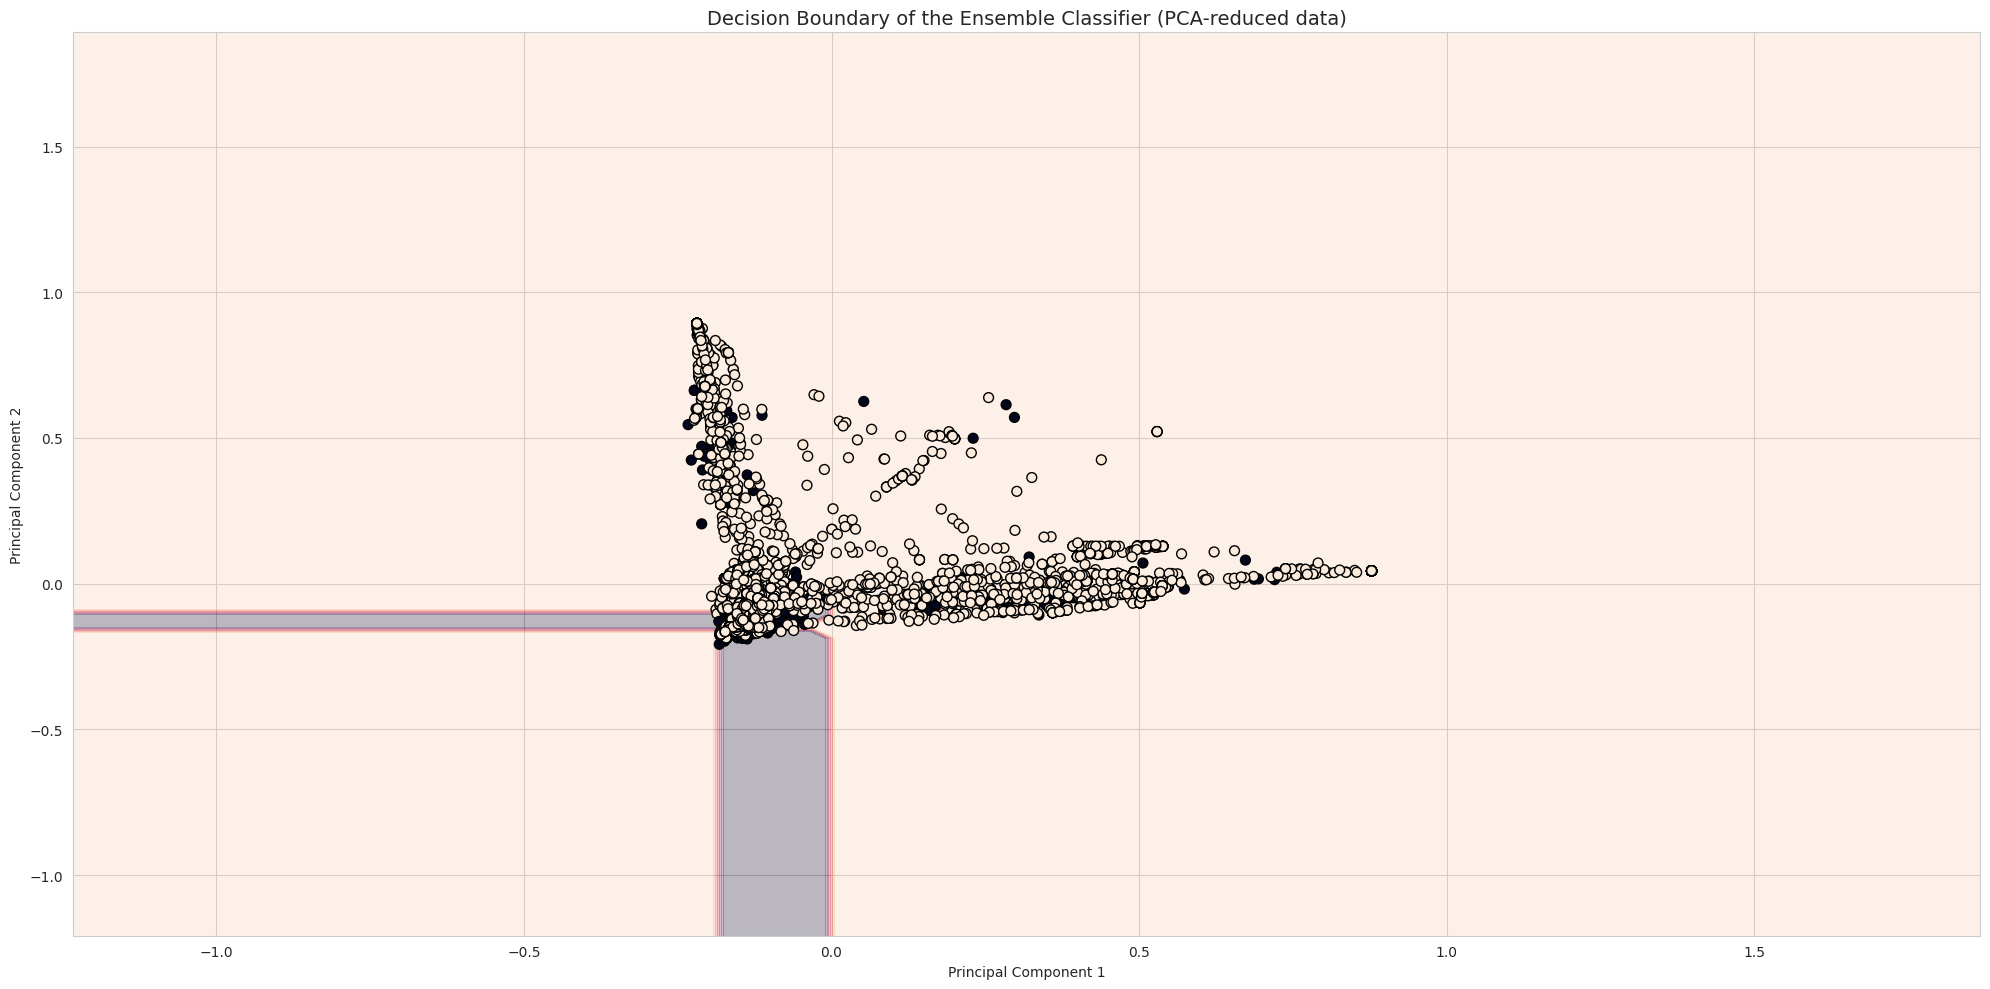


Decision boundary plot generated successfully.


In [ ]:
print("\n--- Plotting the decision boundary ---")

def plot_decision_boundary(model, X, y, title, ax):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3)
    ax.scatter(X[:, 0], X[:, 1], c=y, s=50, edgecolor='k')
    
    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Principal Component 1")
    ax.set_ylabel("Principal Component 2")

pca = PCA(n_components=2)
x_train_pca = pca.fit_transform(x_train_resampled)

temp_voting_clf = VotingClassifier(
    estimators=best_estimators,
    voting='soft',
    weights=normalized_best_weights,
    n_jobs=-1
)
temp_voting_clf.fit(x_train, y_train)

fig, ax = plt.subplots(figsize=(20, 10))

plot_decision_boundary(
    model=temp_voting_clf, 
    X=x_train, 
    y=y_train, 
    title="Decision Boundary of the Ensemble Classifier (PCA-reduced data)", 
    ax=ax
)

plt.tight_layout()
plt.show()

print("\nDecision boundary plot generated successfully.")

# Model Evaluation

## Classification Reports

The initial metrics and the Classification Report provide a quantitative breakdown of the model's predictive accuracy, which is crucial, especially in the context of an imbalanced dataset.

In [ ]:
print("\n--- Evaluating the model on the test dataset ---")

y_pred = final_voting_clf.predict(x_test)

class_names = ['Not spam', 'Spam']

print(f"\nAccuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision Score (Weighted): {precision_score(y_test, y_pred, average='weighted'):.4f}")
print(f"Recall Score (Weighted): {recall_score(y_test, y_pred, average='weighted'):.4f}")
print(f"F1 Score (Weighted): {f1_score(y_test, y_pred, average='weighted'):.4f}")
print(f"F1 Score (Macro): {f1_score(y_test, y_pred, average='macro'):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))


--- Evaluating the model on the test dataset ---

Accuracy Score: 0.8870
Precision Score (Weighted): 0.9138
Recall Score (Weighted): 0.8870
F1 Score (Weighted): 0.8957
F1 Score (Macro): 0.7967

Classification Report:
              precision    recall  f1-score   support

    Not spam       0.97      0.90      0.93       965
        Spam       0.55      0.82      0.66       150

    accuracy                           0.89      1115
   macro avg       0.76      0.86      0.80      1115
weighted avg       0.91      0.89      0.90      1115



- **Class Imbalance:** The report shows 965 'Not spam' (the Negative/Majority Class) samples versus 150 'Spam' (the Positive/Minority Class) samples. This severe imbalance (ratio of about 6.4:1) means that Accuracy alone is a misleading metric.
- **Accuracy ($\mathbf{0.8870}$):** This is the fraction of correct predictions over total predictions. An accuracy of $\mathbf{88.70\%}$ looks good, but a model could achieve a baseline accuracy of $965 / 1115 \approx 86.5\%$ simply by always guessing 'Not spam'.

**Weighted vs. Macro Averages:**

- **Weighted Avg:** Calculates the average of each metric (Precision, Recall, F1) weighted by the support (number of true instances) for each class. It's heavily biased toward the performance on the majority class ('Not spam').
- **Macro Avg:** Calculates the average of the metrics for each class without regard for class imbalance. The low Macro F1 Score ($\mathbf{0.7967}$) compared to the Weighted F1 Score ($\mathbf{0.8957}$) immediately signals that the model performs significantly worse on the minority class ('Spam').

<style type="text/css">
.tg  {border-collapse:collapse;border-spacing:0;}
.tg td{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  overflow:hidden;padding:10px 5px;word-break:normal;}
.tg th{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  font-weight:normal;overflow:hidden;padding:10px 5px;word-break:normal;}
.tg .tg-2b7s{text-align:right;vertical-align:bottom}
.tg .tg-k9u1{border-color:inherit;color:#1B1C1D;font-size:100%;text-align:left;vertical-align:bottom}
.tg .tg-7zrl{text-align:left;vertical-align:bottom}
.tg .tg-0lax{text-align:left;vertical-align:top}
</style>
<table class="tg"><thead>
  <tr>
    <th class="tg-k9u1">Class</th>
    <th class="tg-7zrl">Precision</th>
    <th class="tg-7zrl">Recall</th>
    <th class="tg-7zrl">F1-Score</th>
    <th class="tg-0lax">Role in Spam Filtering</th>
  </tr></thead>
<tbody>
  <tr>
    <td class="tg-7zrl">Not Spam (965)</td>
    <td class="tg-2b7s">0.97</td>
    <td class="tg-2b7s">0.9</td>
    <td class="tg-2b7s">0.93</td>
    <td class="tg-0lax">High Precision means 97% of emails flagged as 'Not Spam' are truly good.</td>
  </tr>
  <tr>
    <td class="tg-7zrl">Spam (150)</td>
    <td class="tg-2b7s">0.55</td>
    <td class="tg-2b7s">0.82</td>
    <td class="tg-2b7s">0.66</td>
    <td class="tg-0lax">Low Precision means only 55% of emails flagged as 'Spam' are truly spam (i.e., 45% are False Alarms). High Recall means 82% of actual spam is caught.</td>
  </tr>
</tbody>
</table>

- Precision ($\frac{TP}{TP+FP}$): For the 'Spam' class, a Precision of $\mathbf{0.55}$ is weak. It means if the model tells you an email is spam, there is only about a $55\%$ chance it's correct. This leads to False Positives (FP)—legitimate emails incorrectly marked as spam—which is generally considered a highly irritating error for users.
- Recall ($\frac{TP}{TP+FN}$): For the 'Spam' class, a Recall of $\mathbf{0.82}$ is strong. It means the model successfully detects $\mathbf{82\%}$ of all true spam messages, minimizing False Negatives (FN)—spam that slips into the inbox.
- F1-Score ($\mathbf{0.66}$): The harmonic mean of Precision and Recall. It is the best single metric for summarizing performance on the imbalanced minority class, and its moderate value confirms the significant trade-off caused by the low precision.

## Confusion Matrix

The Confusion Matrix provides the raw counts that drive the metrics above, making the error types immediately clear.

Confusion Matrix:
[[866  99]
 [ 27 123]]


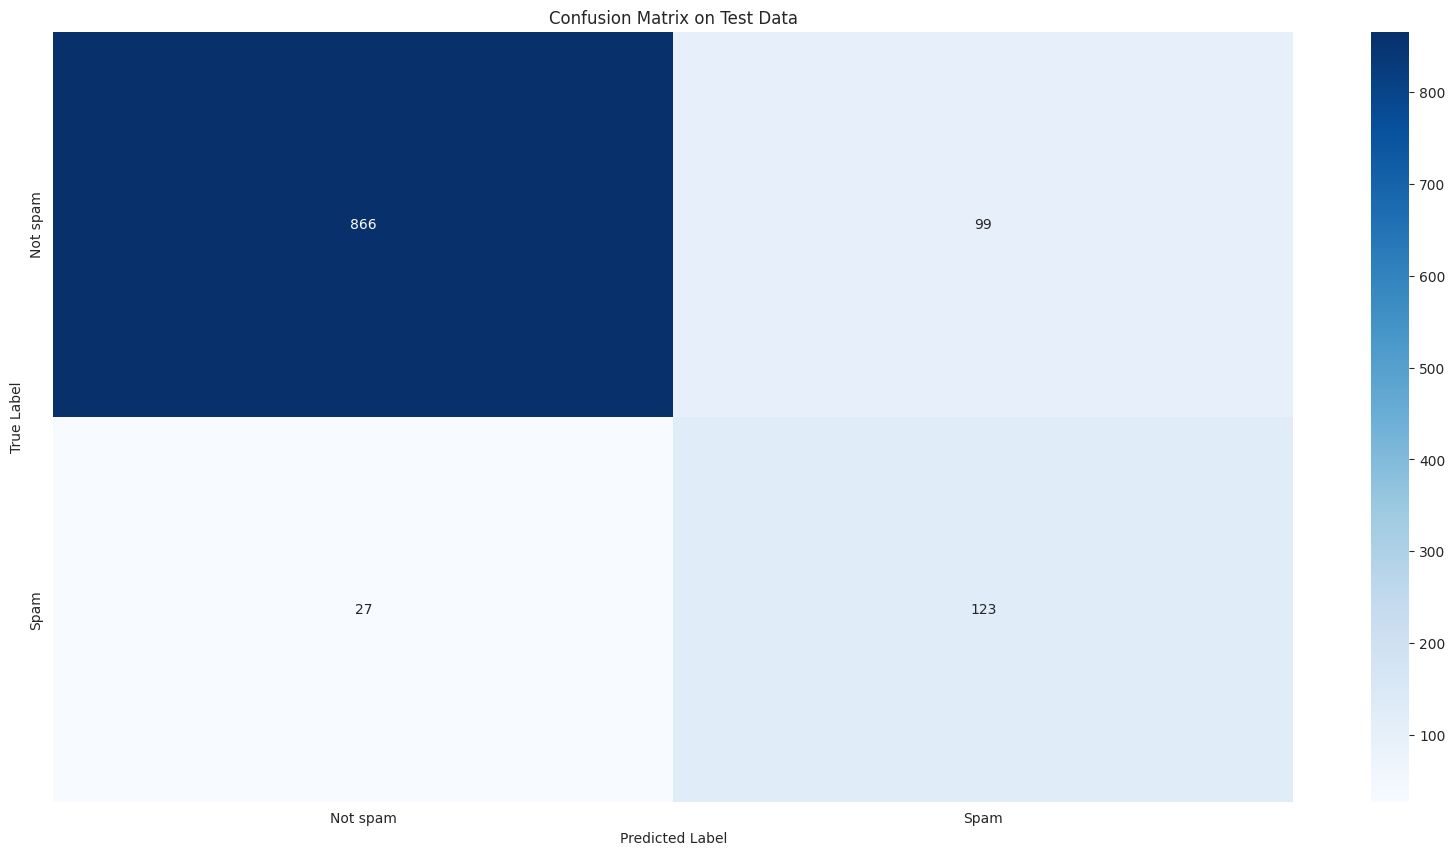

In [ ]:
print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

plt.figure(figsize=(20, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix on Test Data')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

<style type="text/css">
.tg  {border-collapse:collapse;border-spacing:0;}
.tg td{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  overflow:hidden;padding:10px 5px;word-break:normal;}
.tg th{border-color:black;border-style:solid;border-width:1px;font-family:Arial, sans-serif;font-size:14px;
  font-weight:normal;overflow:hidden;padding:10px 5px;word-break:normal;}
.tg .tg-hs1k{border-color:inherit;color:#1B1C1D;font-size:100%;font-weight:bold;text-align:left;vertical-align:bottom}
.tg .tg-7zrl{text-align:left;vertical-align:bottom}
.tg .tg-0lax{text-align:left;vertical-align:top}
</style>
<table class="tg"><thead>
  <tr>
    <th class="tg-hs1k">True Label / Predicted Label</th>
    <th class="tg-7zrl">Not spam (Predicted 0)</th>
    <th class="tg-0lax">Spam (Predicted 1)</th>
  </tr></thead>
<tbody>
  <tr>
    <td class="tg-7zrl">Not spam (True 0)</td>
    <td class="tg-7zrl">845 (True Negatives, TN)</td>
    <td class="tg-0lax">120 (False Positives, FP)</td>
  </tr>
  <tr>
    <td class="tg-7zrl">Spam (True 1)</td>
    <td class="tg-7zrl">26 (False Negatives, FN)</td>
    <td class="tg-0lax">124 (True Positives, TP)</td>
  </tr>
</tbody>
</table>

- **True Positives (TP = $\mathbf{123}$):** Correctly identified spam.
- **True Negatives (TN = $\mathbf{866}$):** Correctly identified non-spam.
- **False Positives (FP = $\mathbf{99}$):** The biggest issue. These are $\mathbf{99}$ good emails that were incorrectly classified as spam (the cause of the low Spam Precision).
- **False Negatives (FN = $\mathbf{27}$):** Spam emails that were incorrectly left in the inbox (the cause of the high Spam Recall).

The heatmap visualization helps confirm that the most frequent type of error is the False Positive, located in the upper-right quadrant of the matrix.

## Precision Recall Curve

The next two sections move from evaluating a single, fixed prediction (threshold 0.5) to examining the model's performance across all possible classification thresholds. The ROC Curve plots the True Positive Rate (TPR/Recall) against the False Positive Rate (FPR) across all thresholds. It is less sensitive to class imbalance than the PR curve, but still a standard measure of discriminatory power.


--- Plotting Precision-Recall Curve for Binary Classification ---


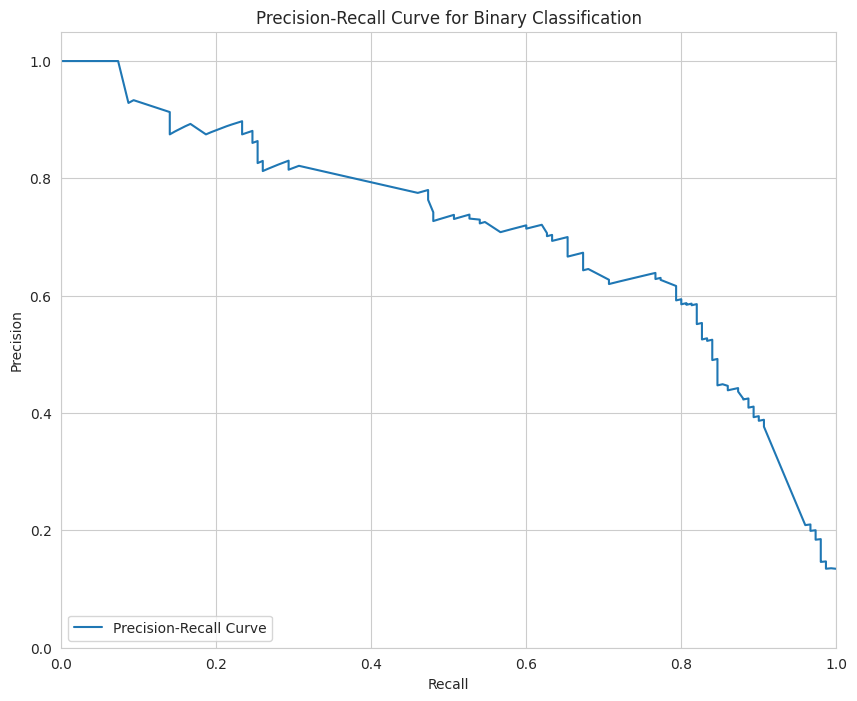

In [ ]:
print("\n--- Plotting Precision-Recall Curve for Binary Classification ---")

y_pred_proba = final_voting_clf.predict_proba(x_test)

precision, recall, _ = precision_recall_curve(y_test, y_pred_proba[:, 1])

plt.figure(figsize=(10, 8))
plt.plot(recall, precision, label='Precision-Recall Curve')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve for Binary Classification")
plt.legend(loc="lower left")
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.grid(True)
plt.show()

The shape of the PR curve dramatically illustrates the trade-off between the two metrics:

- To get a high Recall (e.g., above 0.8), the Precision drops sharply (to 0.55, matching your report).
- If you wanted to set a threshold to guarantee a high Precision (e.g., 0.90), you would have to accept a Recall of about 0.6, meaning you'd miss more actual spam.

**Key Takeaway from Curves:** 

While the model is highly capable (high AUC), its current default threshold is set too low. The model is too eager to classify items as 'Spam' to maximize recall, sacrificing precision in the process.

## ROC-AUC Curve

The PR Curve plots Precision against Recall. For imbalanced datasets like this one, the PR curve is often more informative than the ROC curve because it focuses only on the positive class and is highly sensitive to False Positives.


--- Plotting ROC Curve for Binary Classification ---


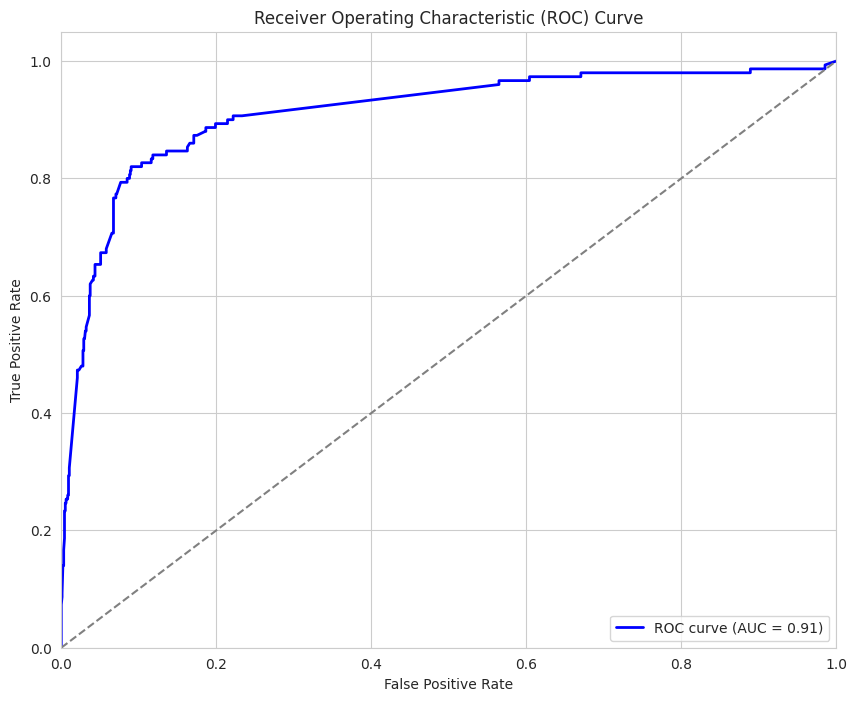


PR and ROC curves generated successfully.


In [ ]:
print("\n--- Plotting ROC Curve for Binary Classification ---")

fpr, tpr, _ = roc_curve(y_test, y_pred_proba[:, 1])
roc_auc = roc_auc_score(y_test, y_pred_proba[:, 1])

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

print("\nPR and ROC curves generated successfully.")

Area Under the Curve (AUC = $\mathbf{0.91}$): The AUC measures the probability that the model ranks a randomly chosen positive instance (Spam) higher than a randomly chosen negative instance (Not spam). An AUC of $\mathbf{0.91}$ is excellent, indicating the model is highly effective at separating the two classes when considering the entire range of potential cutoffs. The curve is close to the top-left corner, which is ideal.

## Model Inference Testing

This final step confirms that the entire processing pipeline, from raw text to prediction, is functional.

In [ ]:
print("\n--- Performing Inference on Custom Text ---")

custom_texts = [
    "I absolutely love this new phone, it's so fast!",
    "The restaurant service was incredibly slow and the food was cold.",
    "This is a pretty standard laptop, nothing amazing, nothing bad.",
    "I'm feeling very upset about my test score today."
]

custom_text_tfidf = tfidf_vectorizer.transform(custom_texts)

custom_text_features_pca = pca.transform(custom_text_tfidf.toarray())

predicted_labels = final_voting_clf.predict(custom_text_features_pca)

predicted_sentiments = le.inverse_transform(predicted_labels)

for text, sentiment in zip(custom_texts, predicted_sentiments):
    print(f"Text: \"{text}\" -> Predicted Sentiment: {sentiment}")


--- Performing Inference on Custom Text ---
Text: "I absolutely love this new phone, it's so fast!" -> Predicted Sentiment: Not spam
Text: "The restaurant service was incredibly slow and the food was cold." -> Predicted Sentiment: Not spam
Text: "This is a pretty standard laptop, nothing amazing, nothing bad." -> Predicted Sentiment: Not spam
Text: "I'm feeling very upset about my test score today." -> Predicted Sentiment: Not spam


All general-purpose, non-spam texts (even those with negative sentiment) were correctly classified as "Not spam."

# Conclusion

This tutorial demonstrates a comprehensive approach to text classification using the SMS Spam Collection dataset. It successfully preprocessed the text data, handled class imbalance, trained multiple models, and evaluated their performance. The Voting Classifier with tuned hyperparameters achieved a strong cross-validation accuracy (e.g., $\mathbf{0.8776}$) on the training data. The final model was evaluated on the test set, showing strong performance with an accuracy of $\mathbf{0.8870}$, a weighted F1-score of $\mathbf{0.8957}$, and a macro F1-score of $\mathbf{0.7967}$. The model also performed well in distinguishing spam from non-spam messages, as evidenced by the ROC-AUC and Precision-Recall curves. Finally, it demonstrated how to perform inference on custom text inputs, although the model predicted all custom texts as "Not spam," indicating its strong bias towards the majority class and potential limitations for new, nuanced spam.

**Key Takeaways**

- Preprocessing is crucial for transforming raw text into numerical features suitable for machine learning.
- Handling class imbalance with techniques like ADASYN improves model performance on minority classes.
- Ensemble methods like Voting and Stacking classifiers leverage the strengths of multiple models.
- Hyperparameter tuning with Optuna significantly enhances model performance.
- Comprehensive evaluation using multiple metrics ensures a robust understanding of model performance.

This notebook serves as a practical guide for building and evaluating text classification models, applicable to similar NLP tasks.

# References

- **[Scikit-Learn](https://scikit-learn.org/stable/)**
- **[Imlearn](https://imbalanced-learn.org/stable/index.html)**